In [1]:
# Cell 1 — Setup and inputs.
#
# Loads the Python libraries used across every subsequent cell (geopandas,
# pyproj, requests, etc.), declares the building input as either an EGID
# (works for 17 EGID-indexed cantons: ZH, BE, ...) or a WGS84 coordinate
# (works anywhere, including non-EGID cantons like VD where the hackathon
# is held, and ZG), creates the tile cache directory under data/ (already
# gitignored via data/), and loads the Google Street View API key from .env
# for later cells.
#
# No network access and no data reads happen here — this is pure
# configuration, the "#define block" of the notebook. Both input options
# should succeed regardless of values because nothing is looked up yet.

from __future__ import annotations

import os
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import requests
from dotenv import load_dotenv

# Pick one input: comment out the others, uncomment the one you want.

# Option A: ZH 140305 — Leuengasse 4 (known WWR test case, run.py default).
# EGID: str | None = "140305"
# LAT: float | None = None
# LON: float | None = None

# Option B: Lausanne coords (VD, non-EGID canton — tests spatial fallback).
# EGID: str | None = None
# LAT: float | None = 46.5197  # near Place St-Francois (Eglise Saint-Francois)
# LON: float | None = 6.6335

# Option C: Bern Old Town — fails because of arcades blocking car-pano coverage.
# EGID: str | None = None
# LAT: float | None = 46.9477
# LON: float | None = 7.4480

# Option D: ZH 141008 — Talstrasse 37, run.py WWR=0.278.
#   Geometry pipeline result with all fixes applied: 0.205.
# EGID: str | None = "141008"
# LAT: float | None = None
# LON: float | None = None

# Option E: ZH 2372629 — run.py WWR=0.020 (low, unusual). Multi-Floor
# stress test (single building stored as two Floor records sharing EGID).
# EGID: str | None = "2372629"
# LAT: float | None = None
# LON: float | None = None

# Option F (active): ZH 140108 — typical Zurich building.
#   Year 1949, 7 storeys, run.py WWR=0.173 (close to dataset mean 0.173).
#   Representative test case — no extreme WWR, no multi-Floor weirdness.
EGID: str | None = "140108"
LAT: float | None = None
LON: float | None = None

REPO_ROOT = Path("/Users/lukemarinos/WORK/glassscan")
DATA_DIR = REPO_ROOT / "data"
TILE_DIR = DATA_DIR / "swissbuildings3d" / "tiles"
TILE_DIR.mkdir(parents=True, exist_ok=True)

load_dotenv(REPO_ROOT / ".env")
GOOGLE_API_KEY = os.environ["GOOGLE_API_KEY"]

STAC_COLLECTION_URL = (
    "https://data.geo.admin.ch/api/stac/v0.9/collections/"
    "ch.swisstopo.swissbuildings3d_3_0"
)

print(f"Tile cache: {TILE_DIR}")
print(f"EGID={EGID}  LAT={LAT}  LON={LON}")


Tile cache: /Users/lukemarinos/WORK/glassscan/data/swissbuildings3d/tiles
EGID=140108  LAT=None  LON=None


In [2]:
# Cell 2 — Inspect the STAC collection metadata.
#
# Makes one HTTPS GET to the swisstopo catalog endpoint. No authentication
# is needed — swisstopo's STAC is fully open. The response is a ~5 KB JSON
# document describing the whole collection (swissBUILDINGS3D 3.0), not
# individual tiles: its spatial extent (all of Switzerland), temporal range
# (when the source data was captured), license, and the hypermedia links
# we follow to reach tile-level Items.
#
# Think of it as the index page of a library rather than any specific book.
# We do this as a cheap contract check: if swisstopo migrates to STAC v1 or
# renames endpoints, this cell fails early and loudly, before we build
# downstream code that silently breaks. The key output to pay attention to
# is the `rel: items` link in the Links block — that's the URL cell 3 hits
# to walk the tiles.

r = requests.get(STAC_COLLECTION_URL, timeout=30)
r.raise_for_status()
collection = r.json()

print("Top-level keys:", list(collection.keys()))
print()
print(f"ID:    {collection.get('id')}")
print(f"Title: {collection.get('title')}")
print()
print("Description (first 300 chars):")
print(collection.get("description", "")[:300])
print()

extent = collection.get("extent", {})
spatial_bbox = extent.get("spatial", {}).get("bbox")
temporal = extent.get("temporal", {}).get("interval")
print(f"Spatial extent (bbox): {spatial_bbox}")
print(f"Temporal extent:       {temporal}")
print()

print("Links:")
for link in collection.get("links", []):
    print(f"  {link.get('rel'):<15} {link.get('href', '')}")


Top-level keys: ['stac_version', 'id', 'title', 'description', 'summaries', 'extent', 'license', 'created', 'updated', 'links', 'crs', 'itemType', 'assets']

ID:    ch.swisstopo.swissbuildings3d_3_0
Title: swissBUILDINGS3D 3.0 Beta

Description (first 300 chars):
swissBUILDINGS3D 3.0 beta is a dataset which describes buildings as 3D-models with roof geometries and roof overhangs. Two variants are available: a model with closed solids and a model with separate elements (roofs, facades and footprints). swissBUILDINGS3D 3.0 provides a useful database for the cr

Spatial extent (bbox): [[5.2229406, 45.3204053, 11.2575962, 48.2425816]]
Temporal extent:       [['2013-01-01T00:00:00Z', '2025-11-26T00:00:00Z']]

Links:
  self            https://data.geo.admin.ch/api/stac/v0.9/collections/ch.swisstopo.swissbuildings3d_3_0
  root            https://data.geo.admin.ch/api/stac/v0.9/
  parent          https://data.geo.admin.ch/api/stac/v0.9/
  items           https://data.geo.admin.ch/api/stac/v0.9

In [3]:
# Cell 3 — Walk the items endpoint (first page, no filter).
#
# Each STAC Item represents one tile — a ~1-6 km square chunk of Switzerland
# with its own WGS84 bbox, capture date, and downloadable assets (a
# .gdb.zip for ESRI and a .dwg.zip for AutoCAD). There are roughly a few
# thousand tiles covering the country.
#
# We fetch page 1 unfiltered to learn the Item structure before narrowing
# down: what does a tile id look like, what MIME types does each carry,
# is the geometry a Polygon, what's in properties. Once we know, cell 5
# will send the SAME endpoint a `?bbox=` query and get back only the
# tile(s) covering our building — so we never actually need to walk all
# pages via the `rel: next` cursor. This cell is purely reconnaissance.

items_url = f"{STAC_COLLECTION_URL}/items"
r = requests.get(items_url, timeout=30)
r.raise_for_status()
items = r.json()

print("Top-level keys:", list(items.keys()))
print(f"Features on this page: {len(items.get('features', []))}")
if "numberMatched" in items:
    print(f"Total tiles in collection: {items['numberMatched']}")
print()

# Pagination links
print("Page links:")
for link in items.get("links", []):
    if link.get("rel") in ("self", "next", "prev", "first"):
        print(f"  {link.get('rel'):<6} {link.get('href', '')}")
print()

# Examine one tile Item in detail
if items.get("features"):
    tile = items["features"][0]
    print("One tile Item:")
    print(f"  id:       {tile.get('id')}")
    print(f"  type:     {tile.get('type')}")
    print(f"  bbox:     {tile.get('bbox')}")
    print(f"  geometry: {type(tile.get('geometry')).__name__}")
    props = tile.get("properties", {})
    print(f"  datetime: {props.get('datetime')}")
    print(f"  assets:")
    for name, asset in tile.get("assets", {}).items():
        href = asset.get("href", "")
        ctype = asset.get("type", "?")
        print(f"    {name}: {href[:90]}")
        print(f"      type={ctype}")


Top-level keys: ['type', 'timeStamp', 'features', 'links']
Features on this page: 100

Page links:
  self   https://data.geo.admin.ch/api/stac/v0.9/collections/ch.swisstopo.swissbuildings3d_3_0/items
  next   https://data.geo.admin.ch/api/stac/v0.9/collections/ch.swisstopo.swissbuildings3d_3_0/items?cursor=cD1zd2lzc2J1aWxkaW5nczNkXzNfMF8yMDE0XzExOTgtMTE%3D

One tile Item:
  id:       swissbuildings3d_3_0_2013_1172-31
  type:     Feature
  bbox:     [8.6202007, 46.9173997, 8.6782508, 46.9449892]
  geometry: dict
  datetime: 2013-01-01T00:00:00Z
  assets:
    swissbuildings3d_3_0_2013_1172-31_2056_5728.dwg.zip: https://data.geo.admin.ch/ch.swisstopo.swissbuildings3d_3_0/swissbuildings3d_3_0_2013_1172
      type=application/x.dwg+zip
    swissbuildings3d_3_0_2013_1172-31_2056_5728.gdb.zip: https://data.geo.admin.ch/ch.swisstopo.swissbuildings3d_3_0/swissbuildings3d_3_0_2013_1172
      type=application/x.filegdb+zip


In [4]:
# Cell 4 — Resolve the input to a canonical pair of coordinates.
#
# Two branches depending on which Option was set in cell 1. If EGID is
# given, we hit the GWR API (api3.geo.admin.ch) which returns the
# building's point location in WGS84 along with its registered attributes:
# address (strname_deinr), construction year (gbauj), storey count (gastw),
# floor area in m2 (garea), volume in m3 (gvol), and category code (gkat).
# These attributes double as features for the predict module and as a
# sanity check later against whatever swissBUILDINGS3D gives us. If
# coordinates were given instead, we skip the API call and pass them
# through.
#
# Exact-match filtering: the GWR /find endpoint is a general-purpose UI
# search that does SUBSTRING matching across numeric fields. A query for
# EGID=140305 returns every building whose EGID contains that string,
# including 1403050, 1403051, ..., 11140305, etc. (We confirmed this:
# 17 fuzzy hits, only 1 exact match.) We therefore post-filter to the
# row whose `egid` attribute equals our query EXACTLY. If no exact match
# exists, we surface the fuzzy hits as suggestions so the user can correct
# a typo without guessing.
#
# In both cases we then reproject WGS84 -> LV95 with pyproj and keep BOTH
# forms. WGS84 is the outside-world language (Google Street View, STAC
# bbox filters, folium basemaps). LV95 is the inside-world language (GDB
# polygons, distance-in-metres math, point-in-polygon against building
# footprints). Reprojecting the single query point once here is cheap; the
# alternative is reprojecting thousands of polygon vertices on the fly
# later, which is both slower and a common source of axis-order bugs.
#
# The `always_xy=True` flag on each Transformer forces (x, y) = (lon, lat)
# for WGS84 and (x, y) = (E, N) for LV95 everywhere. Without it, pyproj
# uses authority-defined axis order which differs per CRS (WGS84 puts lat
# first, LV95 puts E first). Mixing those silently plants buildings in
# the wrong canton; always pin it.

from pyproj import Transformer

to_lv95 = Transformer.from_crs("EPSG:4326", "EPSG:2056", always_xy=True)
to_wgs = Transformer.from_crs("EPSG:2056", "EPSG:4326", always_xy=True)

GWR_FIND_URL = "https://api3.geo.admin.ch/rest/services/api/MapServer/find"

gwr_attrs: dict = {}
if EGID is not None:
    params = {
        "layer": "ch.bfs.gebaeude_wohnungs_register",
        "searchText": EGID,
        "searchField": "egid",
        "returnGeometry": "true",
        "sr": "4326",
    }
    r = requests.get(GWR_FIND_URL, params=params, timeout=30)
    r.raise_for_status()
    results = r.json().get("results", [])
    if not results:
        raise RuntimeError(f"No GWR entry found matching EGID={EGID}")

    # The GWR /find endpoint does SUBSTRING matching, so "140305" hits any
    # building whose egid contains that substring. Filter to exact match.
    exact_hits = [
        h for h in results
        if str(h.get("attributes", {}).get("egid")) == str(EGID)
    ]

    if not exact_hits:
        nearby = sorted(
            {str(h.get("attributes", {}).get("egid"))
             for h in results
             if h.get("attributes", {}).get("egid") is not None}
        )
        raise RuntimeError(
            f"No exact GWR entry for EGID={EGID}. "
            f"The /find endpoint returned {len(results)} fuzzy match(es). "
            f"Did you mean one of these? {nearby[:10]}"
        )

    if len(exact_hits) > 1:
        # Buildings should be uniquely identified by EGID; flag if not.
        print(f"Warning: {len(exact_hits)} buildings share EGID={EGID}; using first.")

    hit = exact_hits[0]
    gwr_attrs = hit.get("attributes", {})
    geom = hit.get("geometry", {})
    LON_WGS = geom.get("x")
    LAT_WGS = geom.get("y")
    print(
        f"GWR: {len(results)} fuzzy hit(s), {len(exact_hits)} exact match for EGID={EGID}."
    )
    print(f"  address:   {gwr_attrs.get('strname_deinr')}")
    print(f"  built:     {gwr_attrs.get('gbauj')}")
    print(f"  storeys:   {gwr_attrs.get('gastw')}")
    print(f"  area_m2:   {gwr_attrs.get('garea')}")
    print(f"  volume_m3: {gwr_attrs.get('gvol')}")
    print(f"  category:  {gwr_attrs.get('gkat')}")
elif LAT is not None and LON is not None:
    LAT_WGS, LON_WGS = LAT, LON
    print(f"Using provided coordinates (no GWR lookup).")
else:
    raise ValueError("Set EGID or both LAT and LON in cell 1")

E_LV95, N_LV95 = to_lv95.transform(LON_WGS, LAT_WGS)

print()
print(f"WGS84:  lat={LAT_WGS:.6f}  lon={LON_WGS:.6f}")
print(f"LV95:   E={E_LV95:.2f}  N={N_LV95:.2f}")


GWR: 16 fuzzy hit(s), 2 exact match for EGID=140108.
  address:   Niederdorfstrasse 10
  built:     1949
  storeys:   7
  area_m2:   708
  volume_m3: 13472
  category:  1040

WGS84:  lat=47.372925  lon=8.543829
LV95:   E=2683470.89  N=1247485.99


In [5]:
# Cell 5 — Find the local tile that covers our building.
#
# Builds a tiny bbox around the WGS84 point (+/- 0.0005 deg, about +/- 50 m)
# and sends it to the STAC items endpoint as
# `?bbox=minlon,minlat,maxlon,maxlat`. The server returns only tile Items
# whose own bbox intersects our query box.
#
# Important finding: swisstopo publishes TWO kinds of Items in this
# collection.
#   1. Regional tiles, e.g. `swissbuildings3d_3_0_2020_1243-14`, each
#      covering a ~6x3 km chunk of Switzerland. File size ~10-20 MB. This
#      is what we want.
#   2. Annual country-wide snapshots, e.g. `swissbuildings3d_3_0_2025`, each
#      a single GDB containing all of Switzerland. File size ~55 GB.
# Any point-bbox query near Switzerland returns both a regional tile AND
# all annual snapshots (because their bboxes span the whole country). We
# must explicitly filter them out or we risk picking a 55 GB download.
# The filter is a bbox-span test: regional tiles are at most ~1 deg wide,
# country-wide items are ~6 deg wide, so any threshold between catches it.
#
# Among the remaining local tiles we pick the one with the most recent
# capture date — swisstopo sometimes has multiple generations of the same
# region (e.g. a 2013 flyover and a 2020 re-flyover) and we want the
# freshest building geometry. The picked download URL is stored as
# GDB_URL for cell 6.
#
# We also pick on MIME type `application/x.filegdb+zip` rather than file
# extension — robust to URL-shape changes — and skip the .dwg.zip AutoCAD
# variant which is painful to read from Python.

eps = 0.0005  # ~50 m; safe for tile-boundary edge cases
bbox = [LON_WGS - eps, LAT_WGS - eps, LON_WGS + eps, LAT_WGS + eps]

params = {"bbox": ",".join(f"{v:.6f}" for v in bbox)}
r = requests.get(f"{STAC_COLLECTION_URL}/items", params=params, timeout=30)
r.raise_for_status()
matches = r.json().get("features", [])

print(f"Query bbox: {params['bbox']}")
print(f"Total matches: {len(matches)}")
print()


def _bbox_span_deg(b: list[float]) -> float:
    """Max side length of a WGS84 bbox in degrees."""
    return max(b[2] - b[0], b[3] - b[1])


# Threshold: regional tiles are at most ~0.1 deg wide; country-wide items
# are ~6 deg wide. 1.0 is comfortably between.
LOCAL_TILE_MAX_SPAN_DEG = 1.0

# Summarise every match, tagging each as country-wide or local.
local_tiles: list[dict] = []
for i, tile in enumerate(matches):
    tid = tile.get("id")
    tbbox = tile.get("bbox", [])
    tdate = tile.get("properties", {}).get("datetime")
    span = _bbox_span_deg(tbbox) if tbbox else float("inf")
    kind = "COUNTRY-WIDE (skipped)" if span > LOCAL_TILE_MAX_SPAN_DEG else "local"
    print(f"[{i}] {tid}  [{kind}]")
    print(f"    bbox span: {span:.3f} deg")
    print(f"    captured:  {tdate}")
    if span <= LOCAL_TILE_MAX_SPAN_DEG:
        local_tiles.append(tile)
print()

if not local_tiles:
    raise RuntimeError(
        "No local tile covers this point — only country-wide snapshots matched."
    )

# Pick the most recently captured local tile.
local_tiles.sort(
    key=lambda t: t.get("properties", {}).get("datetime") or "",
    reverse=True,
)
picked = local_tiles[0]

GDB_URL: str | None = None
TILE_ID = picked.get("id")
TILE_DATETIME = picked.get("properties", {}).get("datetime")

for name, asset in picked.get("assets", {}).items():
    if asset.get("type") == "application/x.filegdb+zip":
        GDB_URL = asset.get("href")
        break

if GDB_URL is None:
    raise RuntimeError("Selected tile has no .gdb.zip asset.")

print(f"Selected tile: {TILE_ID}")
print(f"Captured:      {TILE_DATETIME}")
print(f"GDB URL:       {GDB_URL}")


Query bbox: 8.543329,47.372425,8.544329,47.373425
Total matches: 4

[0] swissbuildings3d_3_0_2019_1091-41  [local]
    bbox span: 0.058 deg
    captured:  2019-01-01T00:00:00Z
[1] swissbuildings3d_3_0_2023  [COUNTRY-WIDE (skipped)]
    bbox span: 6.035 deg
    captured:  2023-11-29T00:00:00Z
[2] swissbuildings3d_3_0_2024  [COUNTRY-WIDE (skipped)]
    bbox span: 6.035 deg
    captured:  2024-11-19T00:00:00Z
[3] swissbuildings3d_3_0_2025  [COUNTRY-WIDE (skipped)]
    bbox span: 6.035 deg
    captured:  2025-11-26T00:00:00Z

Selected tile: swissbuildings3d_3_0_2019_1091-41
Captured:      2019-01-01T00:00:00Z
GDB URL:       https://data.geo.admin.ch/ch.swisstopo.swissbuildings3d_3_0/swissbuildings3d_3_0_2019_1091-41/swissbuildings3d_3_0_2019_1091-41_2056_5728.gdb.zip


In [6]:
# Cell 6 — Download the selected tile's .gdb.zip to the local cache.
#
# Before the actual GET we fire an HTTP HEAD request to get Content-Length.
# This is a safety belt on top of cell 5's country-wide filter: if the URL
# unexpectedly points at a >500 MB file, we abort rather than saturate the
# connection. Any legitimate regional tile is ~10-20 MB, so 500 MB is a
# comfortably loose cap that only catches "something went very wrong".
#
# The download itself uses streaming (stream=True + iter_content) so the
# whole file isn't held in memory at once. Overkill for 20 MB but cheap
# and correct.
#
# We cache by tile id: if `TILE_DIR/<TILE_ID>.gdb.zip` already exists we
# skip the download entirely. This makes the cell idempotent — rerunning
# the whole notebook doesn't re-hit swisstopo every time. Delete the file
# from disk if you ever want to force a fresh pull (e.g. to test a newer
# tile generation).
#
# At the end we have a .gdb.zip on disk. Cell 7 will unzip it, inspect
# what layers live inside (the "separated elements" vs "closed solids"
# variants mentioned in the collection description should become visible
# here) and open them with geopandas.

import shutil

MAX_DOWNLOAD_MB = 500  # safety cap; regional tiles are ~10-20 MB

TILE_ZIP_PATH = TILE_DIR / f"{TILE_ID}.gdb.zip"

if TILE_ZIP_PATH.exists():
    size_mb = TILE_ZIP_PATH.stat().st_size / (1024 * 1024)
    print(f"Already cached: {TILE_ZIP_PATH}")
    print(f"Size:           {size_mb:.1f} MB")
else:
    # HEAD: sanity-check size before committing to the GET
    h = requests.head(GDB_URL, timeout=30, allow_redirects=True)
    h.raise_for_status()
    content_length = int(h.headers.get("Content-Length", 0))
    expected_mb = content_length / (1024 * 1024)
    print(f"HEAD Content-Length: {expected_mb:.1f} MB")

    if expected_mb > MAX_DOWNLOAD_MB:
        raise RuntimeError(
            f"Tile is {expected_mb:.0f} MB, exceeds safety cap "
            f"({MAX_DOWNLOAD_MB} MB). Likely a country-wide snapshot slipped "
            "through cell 5's filter. Investigate before downloading."
        )

    print(f"Downloading to {TILE_ZIP_PATH} ...")
    with requests.get(GDB_URL, stream=True, timeout=300) as r:
        r.raise_for_status()
        with open(TILE_ZIP_PATH, "wb") as f:
            shutil.copyfileobj(r.raw, f, length=1024 * 1024)  # 1 MB chunks

    actual_mb = TILE_ZIP_PATH.stat().st_size / (1024 * 1024)
    print(f"Downloaded:     {actual_mb:.1f} MB")

print()
print(f"Tile zip path:  {TILE_ZIP_PATH}")


Already cached: /Users/lukemarinos/WORK/glassscan/data/swissbuildings3d/tiles/swissbuildings3d_3_0_2019_1091-41.gdb.zip
Size:           120.0 MB

Tile zip path:  /Users/lukemarinos/WORK/glassscan/data/swissbuildings3d/tiles/swissbuildings3d_3_0_2019_1091-41.gdb.zip


In [7]:
# Cell 7 — Extract the .gdb.zip and inspect its layers.
#
# A File Geodatabase (.gdb) is a folder, not a single file. When you
# unzip `<tile>.gdb.zip` you get a folder `<tile>.gdb/` containing
# dozens of .gdbtable / .gdbindexes binary files. Inside are multiple
# LAYERS (think: tables), each holding a different type of feature:
# roofs, walls, floors, closed building solids, etc.
#
# Parsing this GDB is surprisingly fiddly. Two failed approaches
# preceded the one used here:
#
#   1. `fiona.open(path, layer=...)` then `src.schema` — raises
#      `UnsupportedGeometryTypeError: 2147483648` (GDAL code
#      0x80000000, used internally for ESRI MultiPatch). fiona's
#      schema normaliser can't map that to a supported WKB type.
#   2. `pyogrio.list_layers` / `pyogrio.read_info` / even
#      `pyogrio.read_dataframe(read_geometry=False)` — same error
#      from pyogrio's own geometry-type check. Both Python libraries
#      probe the layer's declared geometry type at open time and
#      both choke on the MultiPatch code.
#
# The workaround: skip .schema and iterate features directly. fiona
# can iterate features fine because each feature's own WKB decodes
# to a standard MultiPolygon (the issue is only with the layer-level
# declared type, not with the actual geometries).
#
# Tile isolation: we extract every tile into a tile-specific subdir
# under TILE_DIR (named `<TILE_ID>_extracted/`). This matters when
# you switch the input between EGID (e.g. Zurich) and coordinates
# (e.g. Lausanne) across runs: each lookup hits a different tile,
# and we don't want the old tile's GDB still sitting next to the new
# tile's zip. Without this isolation, the `.gdb` folder name doesn't
# share a substring with TILE_ID (swisstopo uses different casing /
# punctuation) and we'd pick whichever folder existed first.
#
# Expected layers based on the collection description:
#   - Separated elements: Floor, Wall, Roof — per-surface polygons
#     for each building (useful for facade extraction).
#   - Closed solids: Building_solid, Roof_solid — whole buildings
#     as single 3D shells.
# Key fields to look for: EGID (for Option A filter), OBJEKTART
# (building-element type), GESAMTHOEHE (total height), DACH_MIN /
# DACH_MAX (roof lower/upper edge elevations).

import zipfile
import fiona

# Each tile gets its own subdirectory so multiple tiles can coexist on
# disk without ambiguity when switching inputs.
EXTRACT_DIR = TILE_DIR / f"{TILE_ID}_extracted"

existing = list(EXTRACT_DIR.glob("*.gdb")) if EXTRACT_DIR.exists() else []
if not existing:
    print(f"Extracting {TILE_ZIP_PATH.name} -> {EXTRACT_DIR.name}/ ...")
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(TILE_ZIP_PATH) as z:
        z.extractall(EXTRACT_DIR)
    print("Done.")
else:
    print(f"Already extracted in {EXTRACT_DIR.name}/ ({len(existing)} .gdb folder(s)).")
print()

# Find the .gdb folder for this tile under its own extract directory.
# swisstopo's zip might place the .gdb at the top level or nested one
# folder deep, so we check both.
gdbs = sorted(EXTRACT_DIR.glob("*.gdb")) + sorted(EXTRACT_DIR.glob("*/*.gdb"))
if not gdbs:
    raise RuntimeError(
        f"No .gdb folder found inside {EXTRACT_DIR} after extracting "
        f"{TILE_ZIP_PATH.name}. Zip layout may have changed."
    )
GDB_PATH = gdbs[0]
print(f"GDB: {GDB_PATH}")
print()

# fiona.listlayers works because it doesn't parse per-layer schema.
layer_names = fiona.listlayers(str(GDB_PATH))
print(f"Layers ({len(layer_names)}):")
print()

for name in layer_names:
    with fiona.open(str(GDB_PATH), layer=name) as src:
        # These all work without triggering schema parsing.
        n = len(src)
        bounds = src.bounds
        crs = str(src.crs)
        # Touching .schema would raise; pull fields/geom type from first feature.
        first_feat = next(iter(src), None)
        if first_feat is not None:
            fields = list(first_feat["properties"].keys())
            geom = first_feat.get("geometry")
            geom_type = geom["type"] if geom else None
        else:
            fields = []
            geom_type = None
    print(f"  - {name}")
    print(f"      geometry: {geom_type}")
    print(f"      features: {n}")
    print(f"      bounds:   ({bounds[0]:.1f}, {bounds[1]:.1f}) -> ({bounds[2]:.1f}, {bounds[3]:.1f})  [{crs}]")
    print(f"      fields:   {fields}")
    print()


Already extracted in swissbuildings3d_3_0_2019_1091-41_extracted/ (1 .gdb folder(s)).

GDB: /Users/lukemarinos/WORK/glassscan/data/swissbuildings3d/tiles/swissbuildings3d_3_0_2019_1091-41_extracted/swissBUILDINGS3D_3-0_1091-41.gdb

Layers (5):

  - Roof_solid
      geometry: MultiPolygon
      features: 33043
      bounds:   (2681209.0, 1244989.6) -> (2685678.0, 1248030.8)  [EPSG:2056]
      fields:   ['UUID', 'OBJEKTART', 'NAME_KOMPLETT', 'GEBAEUDE_NUTZUNG', 'GRUND_AENDERUNG', 'HERKUNFT', 'HERKUNFT_JAHR', 'HERKUNFT_MONAT', 'ORIGINAL_HERKUNFT', 'ERSTELLUNG_JAHR', 'ERSTELLUNG_MONAT', 'REVISION_JAHR', 'REVISION_MONAT', 'DATUM_AENDERUNG', 'DATUM_ERSTELLUNG', 'DACH_MAX', 'DACH_MIN', 'EGID', 'GEBAEUDEEINHEIT']

  - Building_solid
      geometry: MultiPolygon
      features: 13722
      bounds:   (2681210.1, 1244990.7) -> (2685678.0, 1248025.4)  [EPSG:2056]
      fields:   ['UUID', 'OBJEKTART', 'NAME_KOMPLETT', 'GEBAEUDE_NUTZUNG', 'GRUND_AENDERUNG', 'HERKUNFT', 'HERKUNFT_JAHR', 'HERKUNFT_MON

In [8]:
# Cell 8 — Find our target building inside the GDB.
#
# We query the `Floor` layer because it holds the 2D building
# footprints — the ground-level polygon is the most useful shape for
# downstream rectification, adaptive FOV, and neighbor masking. The
# Wall and Roof layers hold 3D surfaces and are consulted later for
# height and facade extraction.
#
# Two lookup paths, mirroring cell 1's Option A / Option B:
#
#   Option A (EGID is set): we ask fiona to attribute-filter with
#     `src.filter(where="EGID = <egid>")`. GDAL translates this to an
#     OGR SQL expression and uses an index if present; worst case it
#     sequentially scans the ~5000 features in under a second. We
#     still double-check the match in Python in case the where clause
#     returns `None` (driver-dependent).
#
#   Option B (coords only): we want the building that CONTAINS our
#     point. We first narrow candidates with a bbox filter in LV95
#     (~30 m around the query point) — this lets GDAL skip almost all
#     features cheaply — then call shapely's `.contains()` on each
#     remaining polygon for the exact hit. If the point lands in open
#     space (a square, street, park) no polygon contains it and we
#     raise with a helpful message; nudge the coords in cell 1 and
#     re-run.
#
# Output: we save the footprint (LV95), the full attribute record,
# and report a summary. The footprint is a shapely Polygon or
# MultiPolygon we can feed to later cells for projection, centroid,
# neighbor masking, etc.
#
# Final step: cleanup. The Floor layer stores 3D ground surfaces as
# triangulated MultiPatch, so the raw geometry coming out of fiona is
# a MultiPolygon of dozens of small triangles. The hundreds of interior
# edges break downstream edge-based math (visible-facade selection,
# FOV computation, corner enumeration) and clutter the visualisation.
# `.buffer(0)` merges overlapping/touching triangles into a single
# outer polygon, leaving only real building-perimeter edges behind.

from shapely.geometry import Point, shape

target_egid: str | None = None
target_footprint = None
target_attrs: dict = {}

with fiona.open(str(GDB_PATH), layer="Floor") as src:
    if EGID is not None:
        # Option A: attribute filter. Fall back to scan if `where` unsupported.
        # swissBUILDINGS3D sometimes stores one EGID as multiple Floor features
        # (different UUIDs, same physical building). Collect them all and union
        # so the geometry pipeline operates on the whole building, not one part.
        try:
            iter_feats = src.filter(where=f"EGID = {EGID}")
        except Exception:
            iter_feats = iter(src)
        matched_polys = []
        matched_attrs = []
        for feat in iter_feats:
            props = feat["properties"]
            if str(props.get("EGID")) == str(EGID):
                poly = shape(feat["geometry"])
                if not poly.is_empty:
                    matched_polys.append(poly)
                    matched_attrs.append(dict(props))
        if matched_polys:
            from shapely.ops import unary_union
            target_egid = str(EGID)
            target_footprint = unary_union(matched_polys)
            # Pick attrs from the largest part (representative for height etc.)
            largest_idx = max(range(len(matched_polys)),
                              key=lambda i: matched_polys[i].area)
            target_attrs = matched_attrs[largest_idx]
            if len(matched_polys) > 1:
                print(f"  unioned {len(matched_polys)} Floor features sharing EGID {EGID}")
    else:
        # Option B: bbox pre-filter + shapely contains.
        point_lv95 = Point(E_LV95, N_LV95)
        eps_m = 30
        for feat in src.filter(bbox=(
            E_LV95 - eps_m, N_LV95 - eps_m,
            E_LV95 + eps_m, N_LV95 + eps_m,
        )):
            poly = shape(feat["geometry"])
            if poly.contains(point_lv95):
                target_egid = str(feat["properties"].get("EGID"))
                target_footprint = poly
                target_attrs = dict(feat["properties"])
                break

if target_footprint is None:
    msg = (
        f"No Floor polygon matches EGID={EGID}."
        if EGID is not None
        else f"No Floor polygon contains point ({E_LV95:.2f}, {N_LV95:.2f}). "
        f"Query coord may be in open space — nudge LAT/LON in cell 1."
    )
    raise RuntimeError(msg)


def _vertex_count(geom) -> int:
    """Total exterior-ring vertices across (Multi)Polygon parts."""
    if geom.geom_type == "Polygon":
        return len(geom.exterior.coords)
    return sum(len(g.exterior.coords) for g in geom.geoms)


# Cleanup: merge triangulated MultiPatch faces into a single outer polygon.
n_before = _vertex_count(target_footprint)
target_footprint = target_footprint.buffer(0)
n_after = _vertex_count(target_footprint)

# Centroid in both CRS — useful as a canonical "aim at this building" target
# for Street View. Often a better camera target than the input coord, which
# might sit near the building's edge.
centroid_lv95 = target_footprint.centroid
CENTROID_LON, CENTROID_LAT = to_wgs.transform(centroid_lv95.x, centroid_lv95.y)

print(f"Found building: EGID={target_egid}")
print(f"  OBJEKTART:        {target_attrs.get('OBJEKTART')}")
print(f"  GESAMTHOEHE:      {target_attrs.get('GESAMTHOEHE')} m")
print(f"  GEBAEUDE_NUTZUNG: {target_attrs.get('GEBAEUDE_NUTZUNG')}")
print(f"  HERKUNFT:         {target_attrs.get('HERKUNFT')} ({target_attrs.get('HERKUNFT_JAHR')})")
print()
print("Footprint:")
print(f"  geom_type:     {target_footprint.geom_type}")
print(f"  vertices:      {n_before} -> {n_after}  (after .buffer(0) cleanup)")
print(f"  bounds (LV95): {tuple(round(v, 1) for v in target_footprint.bounds)}")
print(f"  area:          {target_footprint.area:.1f} m^2")
print(f"  centroid LV95: ({centroid_lv95.x:.2f}, {centroid_lv95.y:.2f})")
print(f"  centroid WGS:  ({CENTROID_LAT:.6f}, {CENTROID_LON:.6f})")


Found building: EGID=140108
  OBJEKTART:        Gebaeude Einzelhaus
  GESAMTHOEHE:      20.62 m
  GEBAEUDE_NUTZUNG: None
  HERKUNFT:         swisstopo (2019)

Footprint:
  geom_type:     Polygon
  vertices:      66 -> 66  (after .buffer(0) cleanup)
  bounds (LV95): (2683469.1, 1247480.4, 2683506.4, 1247510.2)
  area:          707.9 m^2
  centroid LV95: (2683485.74, 1247496.31)
  centroid WGS:  (47.373016, 8.544028)


In [9]:
# Cell 9 — Visualise the footprint on a real basemap.
#
# Pure sanity check. After cell 8 we have a polygon expressed as LV95
# metres — abstract numbers we can't eyeball. This cell reprojects the
# polygon to WGS84 and drops it on a Leaflet map (via folium) so we
# can confirm visually that we picked the right building.
#
# What the map shows:
#   - red polygon: the matched footprint (target_footprint).
#   - red marker:  the footprint centroid (CENTROID_LAT, CENTROID_LON).
#                  This is the "aim at this building" target we'll hand
#                  to Street View later.
#   - blue marker: your input point (LAT_WGS, LON_WGS).
#                  In Option B this is whatever coord you typed in cell 1;
#                  in Option A it's the GWR-resolved point. The two
#                  markers should sit near each other and inside the
#                  polygon. If they're far apart or outside it, cell 8
#                  matched the wrong building and we should investigate.
#
# Two basemap layers are wired up so you can toggle in the top-right:
#   - OpenStreetMap (default): clearer street labels.
#   - swissimage (aerial photo from swisstopo): best for confirming the
#     building shape against reality.
#
# Reprojection uses shapely.ops.transform with the pyproj `to_wgs`
# Transformer set up in cell 4. Folium's GeoJson layer wants WGS84
# (lon, lat) tuples, which `always_xy=True` already gives us.
#
# VS Code workaround: VS Code's notebook renderer sometimes blocks
# folium's iframe-in-iframe pattern even with the workspace trusted, so
# the map shows folium's "Trust Notebook" fallback rather than Leaflet.
# We always save the map to a standalone HTML file so you can open it
# directly in a browser as a guaranteed fallback. The inline display
# attempt is kept for environments (classic Jupyter, JupyterLab) where
# it works.

import folium
from shapely.ops import transform as shp_transform

footprint_wgs = shp_transform(
    lambda x, y, z=None: to_wgs.transform(x, y),
    target_footprint,
)

m = folium.Map(
    location=[CENTROID_LAT, CENTROID_LON],
    zoom_start=19,
    tiles="OpenStreetMap",
)

# Swiss aerial imagery — better than OSM for confirming building shapes.
folium.TileLayer(
    tiles="https://wmts.geo.admin.ch/1.0.0/ch.swisstopo.swissimage/default/current/3857/{z}/{x}/{y}.jpeg",
    attr="\u00a9 swisstopo",
    name="swissimage (aerial)",
    overlay=False,
).add_to(m)

folium.GeoJson(
    footprint_wgs.__geo_interface__,
    name="target footprint",
    style_function=lambda x: {
        "color": "#d33",
        "weight": 2,
        "fillColor": "#d33",
        "fillOpacity": 0.3,
    },
).add_to(m)

folium.Marker(
    [CENTROID_LAT, CENTROID_LON],
    popup=f"Centroid<br>EGID={target_egid}",
    icon=folium.Icon(color="red"),
).add_to(m)

folium.Marker(
    [LAT_WGS, LON_WGS],
    popup="Input point",
    icon=folium.Icon(color="blue"),
).add_to(m)

folium.LayerControl().add_to(m)

# Standalone HTML fallback — open in a browser if VS Code's notebook
# renderer blocks the inline map.
MAP_HTML_PATH = DATA_DIR / "geometry_single_building_map.html"
m.save(str(MAP_HTML_PATH))
print(f"Map saved to: {MAP_HTML_PATH}")
print(f"Open in browser: file://{MAP_HTML_PATH}")


Map saved to: /Users/lukemarinos/WORK/glassscan/data/geometry_single_building_map.html
Open in browser: file:///Users/lukemarinos/WORK/glassscan/data/geometry_single_building_map.html


In [10]:
# Cell 10 — Decompose the footprint into facade edges with outward normals.
#
# The cleaned target_footprint is a closed polygon; each consecutive pair
# of exterior vertices is one facade. We enumerate them and compute three
# things per edge:
#
#   1. Midpoint (LV95) — used to anchor camera-direction tests later
#      (dot-product with outward normal).
#   2. Length in metres — useful both as a sanity check and to size the
#      destination rectangle in the final homography (a 12 m wide facade
#      should warp to a wider image than a 4 m wide one).
#   3. Outward normal — a unit vector perpendicular to the edge pointing
#      AWAY from the building interior. This is THE key value: dotting it
#      with the vector from edge-midpoint to camera tells us if the facade
#      faces the camera (positive dot = visible) or is on the back side.
#
# Why outward and not inward: shapely follows GeoJSON's right-hand rule
# where the exterior ring of a Polygon goes counter-clockwise in standard
# (E, N) axes — interior on the LEFT as you walk the edge. So the outward
# normal is the 90 degree clockwise rotation of the tangent: tangent
# (dx, dy) -> normal (dy, -dx). We force CCW with shapely's `orient` to
# guarantee this regardless of how fiona handed us the polygon.
#
# We also report the compass bearing of each normal (0 = north, 90 = east,
# etc.) so the edge labelling matches how a person would describe the
# building ("north facade, east facade, ...").
#
# Coords are 3D: swissBUILDINGS3D stores every vertex with a Z elevation
# so a coord tuple is (E, N, Z). For now we work in the 2D ground plane
# and ignore Z — the building height is handled later via GESAMTHOEHE /
# DACH_MAX. We unpack with `*_` to tolerate either 2D or 3D coords.
#
# Output:
#   1. Print table: edge index, length, normal bearing in compass degrees.
#   2. New folium map: the cleaned building outline plus a numbered marker
#      at each edge midpoint and a short arrow showing the outward normal.
#      Saved to data/ as a standalone HTML file alongside cell 9's map.

import math

import folium
from shapely.geometry.polygon import orient

# Force CCW exterior so outward normals are consistent across runs / inputs.
oriented = orient(target_footprint, sign=1.0)


def _iter_exteriors(geom):
    if geom.geom_type == "Polygon":
        yield geom.exterior
    else:
        for g in geom.geoms:
            yield g.exterior


edges: list[dict] = []
last_ring_idx = -1
for ring_idx, ring in enumerate(_iter_exteriors(oriented)):
    last_ring_idx = ring_idx
    coords = list(ring.coords)  # ring is closed: coords[-1] == coords[0]
    for i in range(len(coords) - 1):
        x1, y1, *_ = coords[i]
        x2, y2, *_ = coords[i + 1]
        dx, dy = x2 - x1, y2 - y1
        length = math.hypot(dx, dy)
        if length < 1e-6:
            continue
        tx, ty = dx / length, dy / length        # tangent (unit)
        nx, ny = ty, -tx                          # outward normal (unit)
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2     # midpoint
        bearing = (math.degrees(math.atan2(nx, ny)) + 360) % 360
        edges.append({
            "ring": ring_idx,
            "index": len(edges),
            "p1_lv95": (x1, y1),
            "p2_lv95": (x2, y2),
            "mid_lv95": (mx, my),
            "normal_lv95": (nx, ny),
            "length_m": length,
            "bearing_deg": bearing,
        })

print(f"Found {len(edges)} edge(s) across {last_ring_idx + 1} ring(s):")
print(f"  {'idx':>4}  {'length_m':>10}  {'bearing':>9}")
for e in edges:
    print(f"  {e['index']:>4}  {e['length_m']:>10.2f}  {e['bearing_deg']:>8.1f}\u00b0")

# --- Map overlay --------------------------------------------------------
m2 = folium.Map(
    location=[CENTROID_LAT, CENTROID_LON],
    zoom_start=20,
    tiles="OpenStreetMap",
)
folium.TileLayer(
    tiles="https://wmts.geo.admin.ch/1.0.0/ch.swisstopo.swissimage/default/current/3857/{z}/{x}/{y}.jpeg",
    attr="\u00a9 swisstopo",
    name="swissimage (aerial)",
    overlay=False,
).add_to(m2)

# Building outline (same red as cell 9, no fill so the edges read clearly).
folium.GeoJson(
    footprint_wgs.__geo_interface__,
    name="footprint",
    style_function=lambda x: {
        "color": "#d33",
        "weight": 2,
        "fillColor": "#d33",
        "fillOpacity": 0.0,
    },
).add_to(m2)

# Per-edge: numbered label at midpoint, short arrow along outward normal.
ARROW_LEN_M = 5.0
for e in edges:
    mx, my = e["mid_lv95"]
    nx, ny = e["normal_lv95"]
    tx, ty = mx + ARROW_LEN_M * nx, my + ARROW_LEN_M * ny

    mid_lon, mid_lat = to_wgs.transform(mx, my)
    tip_lon, tip_lat = to_wgs.transform(tx, ty)

    folium.PolyLine(
        [(mid_lat, mid_lon), (tip_lat, tip_lon)],
        color="#0066cc",
        weight=3,
        opacity=0.9,
    ).add_to(m2)
    folium.CircleMarker(
        [tip_lat, tip_lon],
        radius=3,
        color="#0066cc",
        fill=True,
        fill_opacity=1.0,
    ).add_to(m2)
    folium.Marker(
        [mid_lat, mid_lon],
        icon=folium.DivIcon(
            html=(
                f'<div style="font-weight:600;background:white;'
                f'padding:0 4px;border:1px solid #555;border-radius:3px;'
                f'font-size:11px;">{e["index"]}</div>'
            ),
            icon_size=(22, 16),
            icon_anchor=(11, 8),
        ),
    ).add_to(m2)

folium.LayerControl().add_to(m2)

EDGES_HTML_PATH = DATA_DIR / "geometry_single_building_edges.html"
m2.save(str(EDGES_HTML_PATH))
print()
print(f"Edge map saved to: {EDGES_HTML_PATH}")
print(f"Open in browser:   file://{EDGES_HTML_PATH}")

Found 65 edge(s) across 1 ring(s):
   idx    length_m    bearing
     0       19.54     266.9°
     1        1.57     165.2°
     2        4.93     163.8°
     3        0.89     160.2°
     4        8.33     165.6°
     5        0.00     267.6°
     6        5.13     165.6°
     7        4.26     163.0°
     8        0.51     247.7°
     9        1.03     166.1°
    10        2.52     161.0°
    11        1.15      90.8°
    12        2.00      88.1°
    13        0.21     181.5°
    14        4.22      86.0°
    15       13.18     347.0°
    16       13.30     167.0°
    17        0.11      87.9°
    18        4.43      77.2°
    19        0.33     165.1°
    20        2.14      75.8°
    21        0.34     166.6°
    22        1.30     166.6°
    23        0.71     256.6°
    24        0.04     167.2°
    25        1.54      77.7°
    26        3.47     257.7°
    27        1.26     256.6°
    28        2.82     256.7°
    29        0.52     166.5°
    30        0.31     248.6°
    3

In [ ]:
# Cell 11 - Discovery: facade-perpendicular SEEDS + BFS expansion along pano graph.
#
# Two-phase discovery:
#
#   PHASE 1 (seeds): for each major facade edge, probe perpendicular to the
#     facade at a few distances to find a "seed" pano per side of the
#     building. Guarantees at least one camera per facade.
#
#   PHASE 2 (BFS): from each seed, walk the Street View pano graph by
#     probing in 6 directions at small distances (5m, 12m). Each probe
#     returns the NEAREST actual pano within radius. Newly-found panos
#     are queued for further expansion. Adapts to whatever road layout
#     actually exists.
#
# Filters applied to every discovered pano:
#
#   1. INSIDE-A-BUILDING test: if the pano's position falls inside the
#      target's or any neighbour's footprint polygon, reject. This catches
#      indoor / arcade / entrance Trekker panos that Google's "outdoor"
#      filter misses (Google considers covered passageways outdoor).
#
#   2. DISTANCE cap: drop panos beyond MAX_DIST_FROM_BUILDING_M from the
#      building centroid. BFS can wander 50-100m out otherwise; that far
#      a Street View image is too low-resolution + too many things in
#      between to be useful. Also speeds up BFS.
#
#   3. LINE-OF-SIGHT test: 2D ray from pano to each facade midpoint;
#      reject if no facade has clear sight (every line crosses some
#      neighbour). Cell 12 narrows to specific visible edges.
#
#   4. USER-CONTRIBUTED rejection: pano IDs starting with "CAoS" are
#      Trusted Photographer / Trekker panos (user-contributed via
#      Google's programme). They're often INSIDE arcades, museums,
#      train concourses, narrow alleys — Google still classifies them
#      as "outdoor" because covered passageways technically are. The
#      standard Street View car panos use 22-char IDs like
#      "Hdnc2gxNWwHtfy5F3IgnYg" and are reliable for facade work.
#      We always reject CAoS panos for urban facade rectification.
#
#   5. SLITHER rejection: even after passing the above, a pano can show
#      only a thin slice of the building when it's far away, has a short
#      visible edge, or is at a grazing angle. We compute the angular
#      subtense of the BEST visible facade (its perpendicular-projected
#      width / distance) and reject if it's < MIN_FACADE_ANGULAR_SUBTENSE_DEG.
#      Default 15° = building must occupy ~20% of the 70° FOV.
#
#   6. TOO-CLOSE-TO-VISIBLE-FACADE rejection: a pano right up against a
#      wall has huge angular subtense (passes filter 5) but its narrow FOV
#      captures only a few metres of facade — too small to count windows
#      meaningfully. We measure distance from the pano to each VISIBLE
#      edge midpoint (not the whole footprint — that would falsely reject
#      panos sitting close to a side wall that the camera isn't even
#      looking at) and reject if even the closest visible facade is
#      <MIN_DIST_TO_TARGET_WALL_M. Default 5 m is conservative: car-mounted
#      panos sit on roadways which are typically 4-8 m from the facade
#      they're photographing.
#
# Caps: MAX_PANOS limits total panos kept; MAX_API_CALLS hard ceiling on
# metadata requests.
#
# Output (same shape as before, so cell 12 onward unchanged):
#   - panos: list[dict] of viable panos.
#   - PANO_LAT/LON/ID/HEADING_TO_BUILDING/DIST_TO_BUILDING: closest viable.

import math

import folium
from shapely.geometry import LineString, Point, shape
from shapely.ops import transform as shp_transform

from glassscan.fetch.fetch import get_panorama_location, DEFAULT_FOV

MIN_EDGE_LENGTH_M = 3.0
SEED_DISTANCES_M = [12.0, 25.0, 40.0]
BFS_DIRECTIONS_DEG = [0, 60, 120, 180, 240, 300]
BFS_DISTANCES_M = [5.0, 12.0]
PROBE_RADIUS_M = 50
BFS_PROBE_RADIUS_M = 15
NEIGHBOR_BBOX_BUFFER_M = 100.0
MAX_PANOS = 30
MAX_API_CALLS = 400
MAX_DIST_FROM_BUILDING_M = 50.0  # hard cap, measured as distance from pano to nearest target-wall point
MIN_FACADE_ANGULAR_SUBTENSE_DEG = 15.0  # building must occupy at least this much of the FOV
MIN_DIST_TO_TARGET_WALL_M = 5.0  # don't keep panos right up against the wall (FOV captures too little)


def _dist_to_target_m(lat, lon):
    """Min distance in metres from a WGS84 point to the target footprint boundary."""
    e, n = to_lv95.transform(lon, lat)
    return target_footprint.boundary.distance(Point(e, n))


def _haversine_m(lat1, lon1, lat2, lon2):
    R = 6_371_000.0
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dp = math.radians(lat2 - lat1)
    dl = math.radians(lon2 - lon1)
    a = math.sin(dp / 2) ** 2 + math.cos(p1) * math.cos(p2) * math.sin(dl / 2) ** 2
    return 2 * R * math.asin(math.sqrt(a))


def _bearing_deg(lat1, lon1, lat2, lon2):
    p1, p2 = math.radians(lat1), math.radians(lat2)
    dl = math.radians(lon2 - lon1)
    x = math.sin(dl) * math.cos(p2)
    y = math.cos(p1) * math.sin(p2) - math.sin(p1) * math.cos(p2) * math.cos(dl)
    return (math.degrees(math.atan2(x, y)) + 360) % 360


def _offset_latlon(lat, lon, bearing_deg, dist_m):
    R = 6_371_000.0
    lat_r = math.radians(lat)
    lon_r = math.radians(lon)
    b_r = math.radians(bearing_deg)
    d = dist_m / R
    new_lat = math.asin(
        math.sin(lat_r) * math.cos(d) + math.cos(lat_r) * math.sin(d) * math.cos(b_r)
    )
    new_lon = lon_r + math.atan2(
        math.sin(b_r) * math.sin(d) * math.cos(lat_r),
        math.cos(d) - math.sin(lat_r) * math.sin(new_lat),
    )
    return math.degrees(new_lat), math.degrees(new_lon)


# --- Load neighbour footprints -----------------------------------------
target_bounds = target_footprint.bounds
neighbor_bbox = (
    target_bounds[0] - NEIGHBOR_BBOX_BUFFER_M,
    target_bounds[1] - NEIGHBOR_BBOX_BUFFER_M,
    target_bounds[2] + NEIGHBOR_BBOX_BUFFER_M,
    target_bounds[3] + NEIGHBOR_BBOX_BUFFER_M,
)
print(f"Loading neighbour footprints in {NEIGHBOR_BBOX_BUFFER_M:.0f}m buffer...")
nearby_buildings = []
with fiona.open(str(GDB_PATH), layer="Floor") as src:
    for feat in src.filter(bbox=neighbor_bbox):
        # Exclude any Floor feature with our target EGID — swissBUILDINGS3D
        # sometimes stores one building as multiple Floor records (different
        # UUIDs but same EGID). UUID-only exclusion would leave the other
        # parts in nearby_buildings and they would falsely block LOS.
        if str(feat["properties"].get("EGID")) == str(target_egid):
            continue
        try:
            poly = shape(feat["geometry"]).buffer(0)
            if not poly.is_empty:
                nearby_buildings.append(poly)
        except Exception:
            continue
print(f"  -> {len(nearby_buildings)} neighbours loaded.")

# All buildings (target + neighbours) for the inside-a-building test.
all_buildings_for_inside_test = [target_footprint] + nearby_buildings

# --- API-call accounting -----------------------------------------------
api_call_count = 0


def _probe(lat, lon, radius):
    global api_call_count
    if api_call_count >= MAX_API_CALLS:
        return None
    api_call_count += 1
    return get_panorama_location(lat, lon, GOOGLE_API_KEY, radius=radius)


# --- PHASE 1: seeds -----------------------------------------------------
major_edges = [e for e in edges if e["length_m"] >= MIN_EDGE_LENGTH_M]
print(f"Major edges (length >= {MIN_EDGE_LENGTH_M}m): {len(major_edges)} of {len(edges)}")

discovered = {}
print()
print(f"PHASE 1: facade-perpendicular seeds "
      f"({len(major_edges)} edges x {len(SEED_DISTANCES_M)} distances)...")
for e in major_edges:
    mx, my = e["mid_lv95"]
    nx, ny = e["normal_lv95"]
    for dist in SEED_DISTANCES_M:
        ideal_e = mx + nx * dist
        ideal_n = my + ny * dist
        ideal_lon, ideal_lat = to_wgs.transform(ideal_e, ideal_n)
        result = _probe(ideal_lat, ideal_lon, PROBE_RADIUS_M)
        if result is None:
            continue
        pano_lat, pano_lon, pano_id = result
        if pano_id not in discovered:
            discovered[pano_id] = {
                "pano_id": pano_id,
                "lat": pano_lat,
                "lon": pano_lon,
                "source": "seed",
                "via_edge": e["index"],
            }
print(f"  -> {len(discovered)} unique panos from seed phase ({api_call_count} calls).")

# --- PHASE 2: BFS expansion --------------------------------------------
print()
print(f"PHASE 2: BFS expansion (max {MAX_PANOS} panos, {MAX_DIST_FROM_BUILDING_M:.0f}m cap)...")
queue = [(p["pano_id"], p["lat"], p["lon"]) for p in discovered.values()]
bfs_attempts = 0
while queue and len(discovered) < MAX_PANOS and api_call_count < MAX_API_CALLS:
    pid, plat, plon = queue.pop(0)
    # Don't expand from panos already too far from the building.
    if _dist_to_target_m(plat, plon) > MAX_DIST_FROM_BUILDING_M:
        continue
    for direction in BFS_DIRECTIONS_DEG:
        for dist in BFS_DISTANCES_M:
            probe_lat, probe_lon = _offset_latlon(plat, plon, direction, dist)
            bfs_attempts += 1
            result = _probe(probe_lat, probe_lon, BFS_PROBE_RADIUS_M)
            if result is None:
                continue
            new_lat, new_lon, new_id = result
            if new_id in discovered:
                continue
            discovered[new_id] = {
                "pano_id": new_id,
                "lat": new_lat,
                "lon": new_lon,
                "source": "bfs",
                "expanded_from": pid,
            }
            queue.append((new_id, new_lat, new_lon))
            if len(discovered) >= MAX_PANOS:
                break
        if len(discovered) >= MAX_PANOS:
            break

print(f"  -> {len(discovered)} total panos after BFS ({bfs_attempts} BFS probes, "
      f"{api_call_count} total calls).")
if api_call_count >= MAX_API_CALLS:
    print(f"  WARNING: hit MAX_API_CALLS={MAX_API_CALLS}.")
if len(discovered) >= MAX_PANOS:
    print(f"  WARNING: hit MAX_PANOS={MAX_PANOS}.")

# --- Filter: inside-building, distance, line-of-sight ------------------
print()
print(f"Filtering {len(discovered)} discovered panos...")


def _is_inside_any_building(pano_e, pano_n, polys) -> bool:
    pt = Point(pano_e, pano_n)
    return any(p.contains(pt) for p in polys)


def _angular_extent_deg(angles_deg) -> float:
    """Smallest arc (in degrees) that contains all of the given compass
    angles (0..360). Handles wrap-around correctly: e.g. [350, 5, 10]
    returns 20, not 350."""
    if len(angles_deg) < 2:
        return 0.0
    a = sorted(x % 360 for x in angles_deg)
    n = len(a)
    gaps = [a[(i + 1) % n] - a[i] for i in range(n - 1)]
    gaps.append((a[0] + 360) - a[-1])
    return 360.0 - max(gaps)


def _building_angular_extent_deg(
    pano_e, pano_n, edge_list, visible_edge_idxs
) -> float:
    """Smallest arc from the camera that contains all endpoints of every
    visible edge. This is the angular WIDTH the building would occupy in
    an optimally-aimed camera. Handles multi-edge / corner views correctly:
    a camera at a corner sees two walls at oblique angles, neither big on
    its own, but together they span a wide arc. Capped at DEFAULT_FOV
    (the camera can't actually display more than that)."""
    visible_set = set(visible_edge_idxs)
    angles = []
    for e in edge_list:
        if e["index"] not in visible_set:
            continue
        for pt in (e["p1_lv95"], e["p2_lv95"]):
            dE = pt[0] - pano_e
            dN = pt[1] - pano_n
            if abs(dE) < 1e-9 and abs(dN) < 1e-9:
                continue
            angles.append(math.degrees(math.atan2(dE, dN)) % 360)
    extent = _angular_extent_deg(angles)
    return min(extent, float(DEFAULT_FOV))


def _has_clear_los_to_any_facade(pano_e, pano_n, edge_list, others) -> tuple[bool, list[int]]:
    visible_edge_idxs = []
    for e in edge_list:
        mx, my = e["mid_lv95"]
        ray = LineString([(pano_e, pano_n), (mx, my)])
        if not any(ray.crosses(b) for b in others):
            visible_edge_idxs.append(e["index"])
    return (len(visible_edge_idxs) > 0, visible_edge_idxs)


panos = []
rejected_inside = []
rejected_far = []
rejected_los = []
rejected_user = []  # CAoS-prefixed (Trekker / Trusted Photographer)
rejected_slither = []  # building takes up too little of the FOV
rejected_close = []  # too close to target wall
for info in discovered.values():
    pano_e, pano_n = to_lv95.transform(info["lon"], info["lat"])
    record = {
        "pano_id": info["pano_id"],
        "lat": info["lat"],
        "lon": info["lon"],
        "distance_m": _dist_to_target_m(info["lat"], info["lon"]),
        "heading_to_building": _bearing_deg(info["lat"], info["lon"], CENTROID_LAT, CENTROID_LON),
        "source": info["source"],
        "found_via_edges": [],
    }
    # 0. User-contributed pano check (CAoS-prefixed Trekker / Trusted Photographer).
    # Reject these — they're often inside arcades / passageways even though
    # Google's "outdoor" filter passed them through.
    if info["pano_id"].startswith("CAoS"):
        rejected_user.append(record)
        continue
    # 1. Inside-a-building check (catches arcade / Trekker indoor leakage)
    pano_pt = Point(pano_e, pano_n)
    if _is_inside_any_building(pano_e, pano_n, all_buildings_for_inside_test):
        rejected_inside.append(record)
        continue
    # 2. Distance cap
    if record["distance_m"] > MAX_DIST_FROM_BUILDING_M:
        rejected_far.append(record)
        continue
    # 3. Line-of-sight test (must come before too-close + slither, since
    #    those need to know which edges are visible from this pano).
    has_los, vis_edges = _has_clear_los_to_any_facade(
        pano_e, pano_n, major_edges, nearby_buildings
    )
    record["found_via_edges"] = vis_edges
    if not has_los:
        rejected_los.append(record)
        continue
    # 4. Too-close-to-VISIBLE-facade check. Use proper line-segment
    #    distance from pano to each visible edge (Point.distance(LineString)
    #    handles "perpendicular within segment" vs "to nearest endpoint"
    #    correctly). Midpoint-only distance would mis-classify panos near
    #    an edge end.
    edges_by_idx = {e["index"]: e for e in major_edges}
    visible_dist_by_idx = {}
    for idx in vis_edges:
        e = edges_by_idx[idx]
        p1 = e["p1_lv95"]
        p2 = e["p2_lv95"]
        edge_line = LineString([p1, p2])
        visible_dist_by_idx[idx] = pano_pt.distance(edge_line)
    if visible_dist_by_idx:
        nearest_idx = min(visible_dist_by_idx, key=visible_dist_by_idx.get)
        nearest_visible_facade_m = visible_dist_by_idx[nearest_idx]
    else:
        nearest_idx = None
        nearest_visible_facade_m = float("inf")
    record["nearest_visible_facade_m"] = nearest_visible_facade_m
    record["nearest_visible_edge_idx"] = nearest_idx
    record["per_edge_distances_m"] = visible_dist_by_idx
    if nearest_visible_facade_m < MIN_DIST_TO_TARGET_WALL_M:
        rejected_close.append(record)
        continue
    # 5. Slither check: combined angular extent of visible edges (i.e.
    #    how wide the building would appear in an optimally-aimed camera).
    extent = _building_angular_extent_deg(
        pano_e, pano_n, major_edges, vis_edges
    )
    record["building_angular_extent_deg"] = extent
    if extent < MIN_FACADE_ANGULAR_SUBTENSE_DEG:
        rejected_slither.append(record)
        continue
    panos.append(record)

panos.sort(key=lambda p: p["distance_m"])

print(f"  -> {len(panos)} viable")
print(f"     rejected: {len(rejected_user)} user-contributed (CAoS), "
      f"{len(rejected_inside)} inside-building, "
      f"{len(rejected_close)} too close (<{MIN_DIST_TO_TARGET_WALL_M:.0f}m to wall), "
      f"{len(rejected_far)} too far (>{MAX_DIST_FROM_BUILDING_M:.0f}m), "
      f"{len(rejected_los)} line-of-sight blocked, "
      f"{len(rejected_slither)} slither (<{MIN_FACADE_ANGULAR_SUBTENSE_DEG:.0f}° subtense)")

if not panos:
    raise RuntimeError(
        "No viable panos. Check the discovery map - rejected red dots will "
        "tell you which filter killed each candidate."
    )

# --- Photometa position correction ------------------------------------
# Static API metadata reports a snapped/reverse-geocoded position which
# can differ from the actual capture position by ~10m (in Zurich Altstadt
# 2021-vintage panos the offset is consistently westward, likely a
# road-snapping artifact). Google's image renderer uses the actual
# capture position internally, so projection coords aligned to Static
# API land ~22° off in the rendered image at typical 25m distance.
# Photometa returns the actual capture position; switch the canonical
# lat/lon to photometa where available, fall back to Static API if not.
from glassscan.fetch.photometa import query_photometa
import time as _time

PHOTOMETA_CACHE_DIR = DATA_DIR / "photometa_cache"
_corrections_m = []
_n_resolved = 0
_all_records = (panos + rejected_user + rejected_inside + rejected_close +
                rejected_far + rejected_los + rejected_slither)
for _r in _all_records:
    _r["lat_static"] = _r["lat"]
    _r["lon_static"] = _r["lon"]
    _pm = query_photometa(_r["pano_id"], cache_dir=PHOTOMETA_CACHE_DIR)
    if _pm is None:
        _r["pano_yaw"] = None
        _r["imagery_year"] = None
        _r["imagery_month"] = None
        _r["position_source"] = "static"
        continue
    _r["lat"] = _pm["lat"]
    _r["lon"] = _pm["lon"]
    _r["pano_yaw"] = _pm["pano_yaw"]
    _r["imagery_year"] = _pm["imagery_year"]
    _r["imagery_month"] = _pm["imagery_month"]
    _r["position_source"] = "photometa"
    # Recompute downstream-relevant derived values from corrected position.
    _r["distance_m"] = _dist_to_target_m(_pm["lat"], _pm["lon"])
    _r["heading_to_building"] = _bearing_deg(
        _pm["lat"], _pm["lon"], CENTROID_LAT, CENTROID_LON
    )
    _corrections_m.append(_haversine_m(
        _r["lat_static"], _r["lon_static"], _pm["lat"], _pm["lon"]
    ))
    _n_resolved += 1
    _time.sleep(0.05)  # fair-use throttle on undocumented endpoint

# Re-sort viable panos by corrected distance.
panos.sort(key=lambda p: p["distance_m"])

if _corrections_m:
    import statistics as _stats
    print()
    print(f"Photometa: {_n_resolved}/{len(_all_records)} panos resolved, "
          f"median correction {_stats.median(_corrections_m):.1f}m, "
          f"max {max(_corrections_m):.1f}m")

# --- Print summary -----------------------------------------------------
print()
print(f"  {'idx':>3}  {'src':>4}  {'pano_id':>22}  {'lat':>10}  {'lon':>9}  "
      f"{'dist_m':>7}  {'heading':>8}  {'subtense':>8}  visible_edges")
for i, p in enumerate(panos):
    pid = (p["pano_id"] or "")[:22]
    print(
        f"  {i:>3}  {p['source']:>4}  {pid:>22}  {p['lat']:>10.6f}  {p['lon']:>9.6f}  "
        f"{p['distance_m']:>7.1f}  {p['heading_to_building']:>7.1f}°  "
        f"{p['building_angular_extent_deg']:>7.1f}°  {p['found_via_edges'][:8]}"
    )

PANO_LAT = panos[0]["lat"]
PANO_LON = panos[0]["lon"]
PANO_ID = panos[0]["pano_id"]
HEADING_TO_BUILDING = panos[0]["heading_to_building"]
DIST_TO_BUILDING = panos[0]["distance_m"]
print()
print(f"Default selected pano (closest viable): #0 dist={DIST_TO_BUILDING:.1f}m "
      f"heading={HEADING_TO_BUILDING:.1f}°")

# --- Pano-image popup helper ------------------------------------------
# Map markers can show the actual Street View capture when clicked. The
# image cache is populated by cell 11b; on first run the popups show a
# placeholder. _sanitize_pano_id mirrors the sanitiser cell 11b uses for
# the cache filename so we look up the same key.
import base64 as _b64
import io as _io

def _sanitize_pano_id(pid):
    """Make a pano_id safe for a filename: keep [A-Za-z0-9_-]."""
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in pid)

def _make_pano_popup_html(pano_id, heading_to_building, label, dist_m=None,
                          max_dim=240):
    """HTML for a folium popup: cached pano image (if available) + metadata."""
    cache_dir = DATA_DIR / "discovery_debug_images"
    img_path = cache_dir / f"pano_{_sanitize_pano_id(pano_id)}_h{int(heading_to_building)}.jpg"
    if img_path.exists() and img_path.stat().st_size > 1000:
        from PIL import Image as _PILImage
        img = _PILImage.open(img_path).convert("RGB")
        img.thumbnail((max_dim, max_dim))
        buf = _io.BytesIO()
        img.save(buf, format="JPEG", quality=72)
        b64 = _b64.b64encode(buf.getvalue()).decode()
        img_html = (f'<img src="data:image/jpeg;base64,{b64}" '
                    f'style="max-width:{max_dim}px;display:block;"/>')
    else:
        img_html = ('<i style="color:#888;font-size:11px;">image not cached '
                    '(run cell 11b first)</i>')
    meta = f"<div style='font-size:11px;margin-top:4px;'><b>{label}</b>"
    if dist_m is not None:
        meta += f"<br>dist={dist_m:.1f}m"
    meta += f"<br>heading={int(heading_to_building)}°<br>pano_id={pano_id[:18]}..."
    meta += "</div>"
    return img_html + meta


# --- Global indices across viable + rejected panos ---------------------
# Every pano gets a unique #N so map markers, table rows, and cell 11b
# debug images can all be cross-referenced.
all_pano_records = []
def _add_with_idx(items, status):
    for r in items:
        rec = dict(r)
        rec["status"] = status
        all_pano_records.append(rec)
_add_with_idx(panos, "viable")
_add_with_idx(rejected_user, "rej:user")
_add_with_idx(rejected_inside, "rej:inside")
_add_with_idx(rejected_close, "rej:close")
_add_with_idx(rejected_far, "rej:far")
_add_with_idx(rejected_los, "rej:los")
_add_with_idx(rejected_slither, "rej:slither")
for i, r in enumerate(all_pano_records):
    r["global_idx"] = i

# Map global_idx by pano_id so the map loop below can look them up.
GLOBAL_IDX_BY_PANO_ID = {r["pano_id"]: r["global_idx"] for r in all_pano_records}

print()
print(f"Full pano table ({len(all_pano_records)} discovered):")
print(f"  {'#':>3}  {'status':>10}  {'src':>4}  {'dist_m':>7}  {'wall_m':>6}  "
      f"{'near_e':>6}  {'pano_id':>34}")
for r in all_pano_records:
    pid = (r["pano_id"] or "")[:34]
    wall = r.get("nearest_visible_facade_m")
    wall_str = f"{wall:>5.1f}" if (wall is not None and wall < 1e6) else "  -- "
    near = r.get("nearest_visible_edge_idx")
    near_str = f"#{near}" if near is not None else "  -- "
    print(f"  {r['global_idx']:>3}  {r['status']:>10}  {r['source']:>4}  "
          f"{r['distance_m']:>7.1f}  {wall_str}  {near_str:>6}  {pid:>34}")



Fetching images (cached after first run)...
Fetched 30 images total.



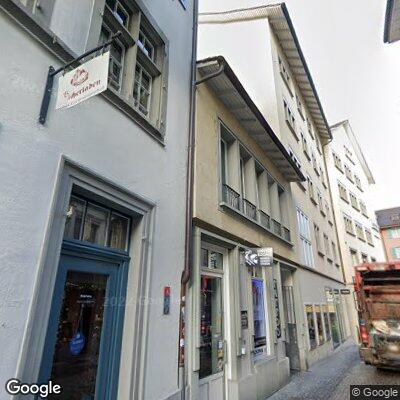
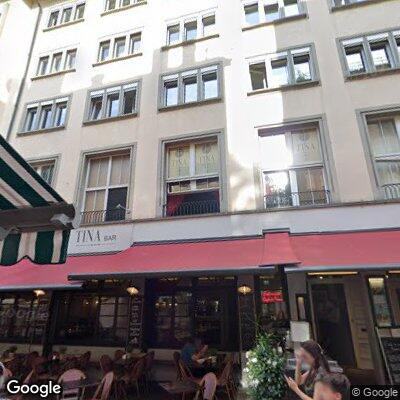
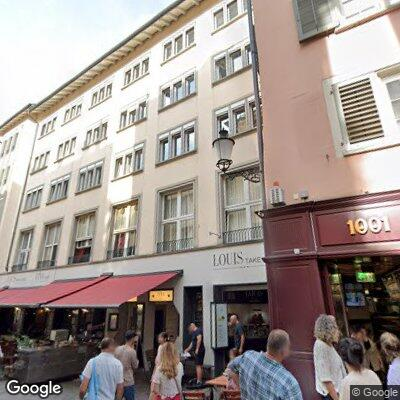
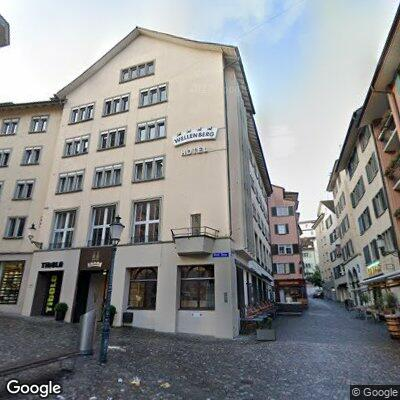
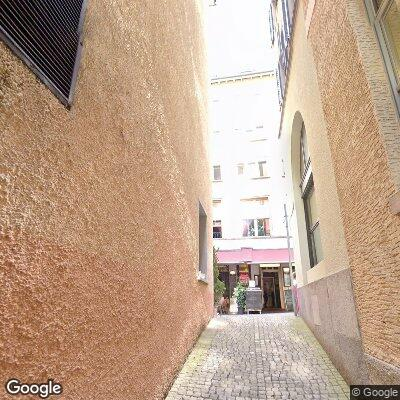
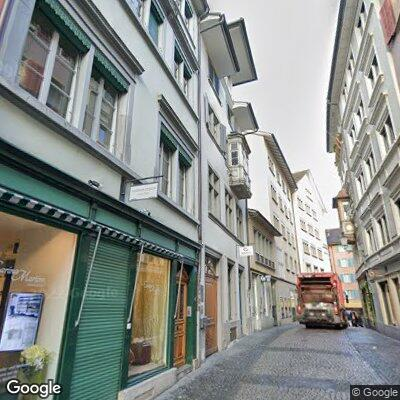
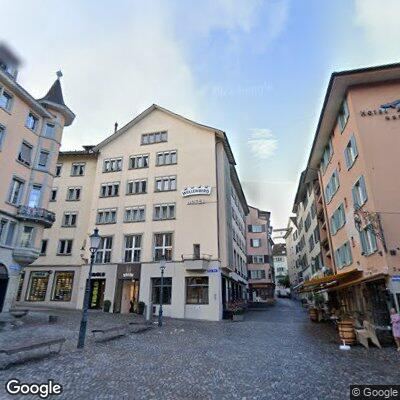
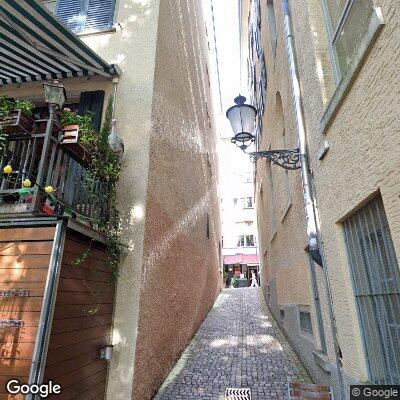
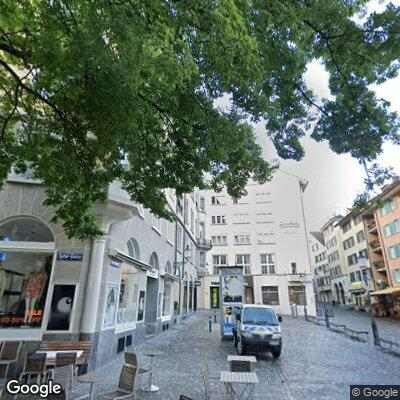
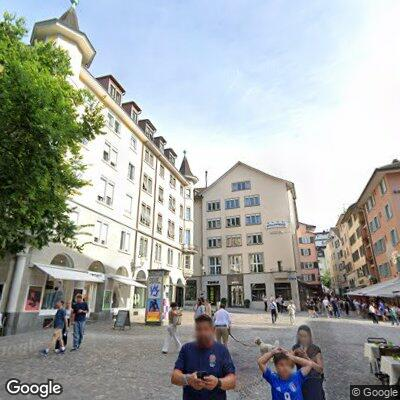
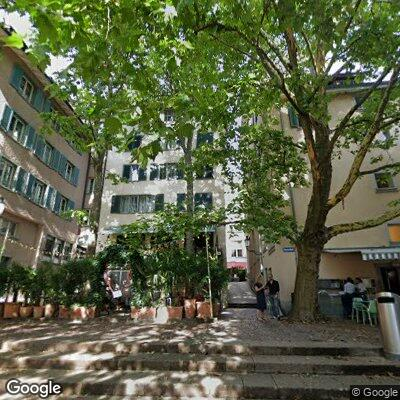
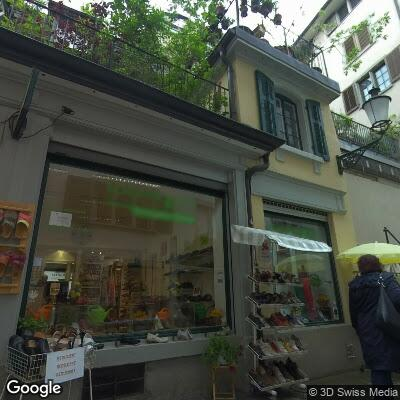
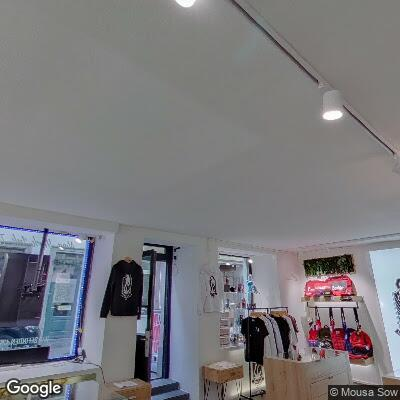
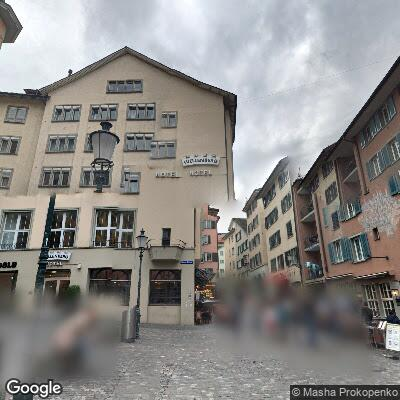
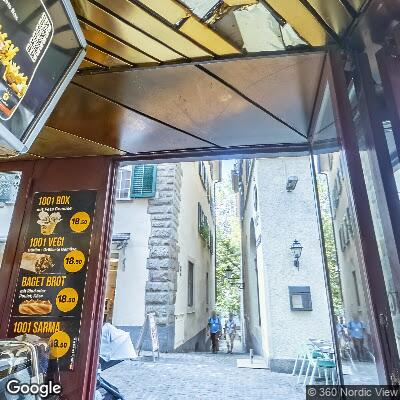
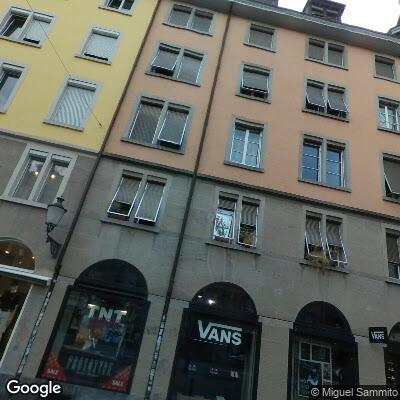
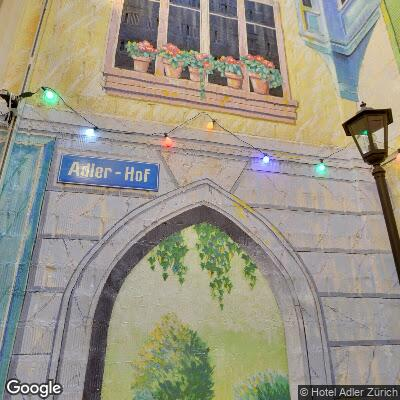
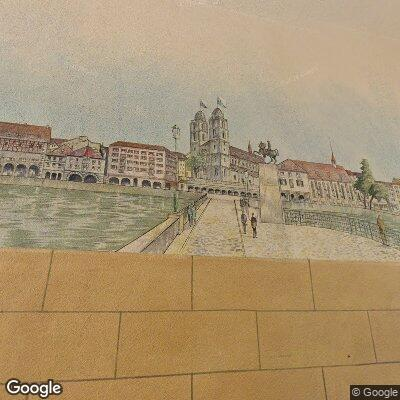
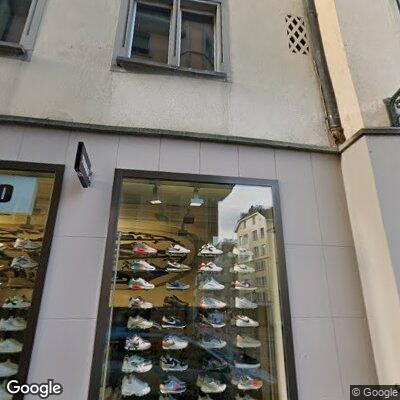
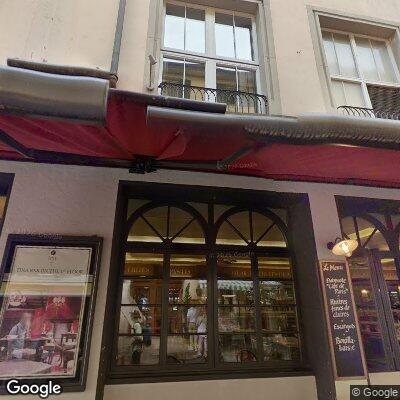
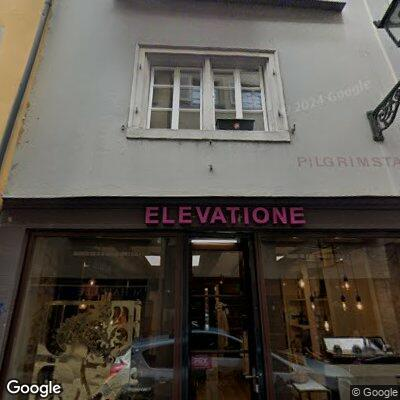
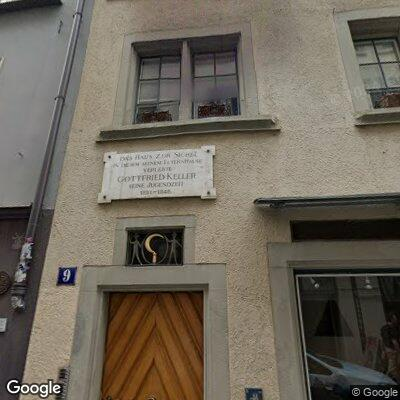
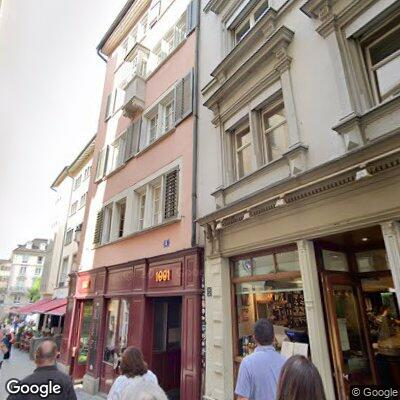
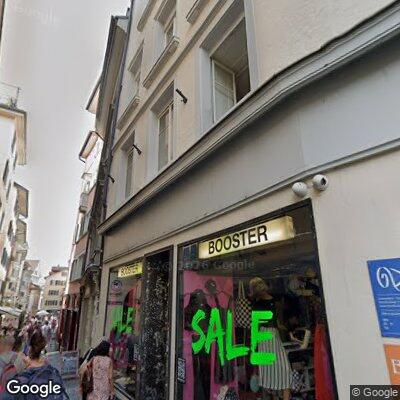
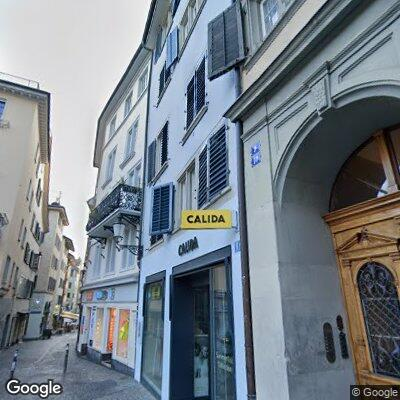
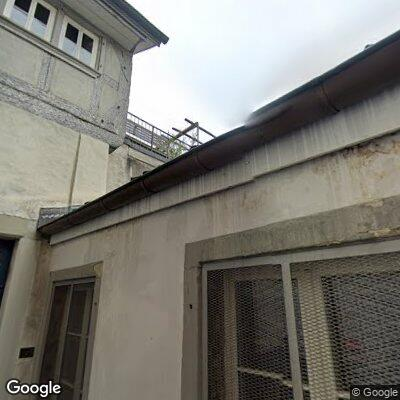
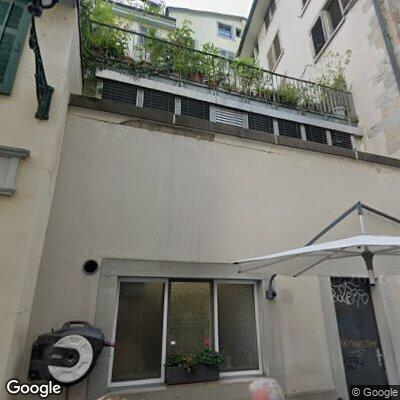
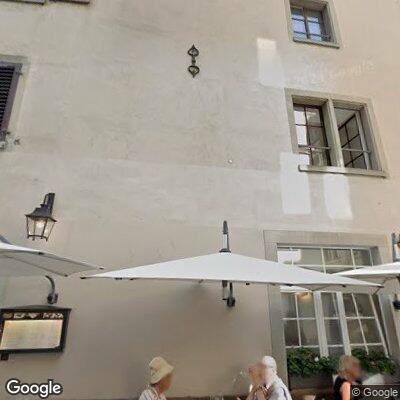
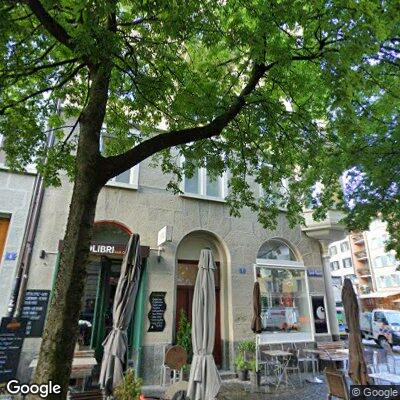
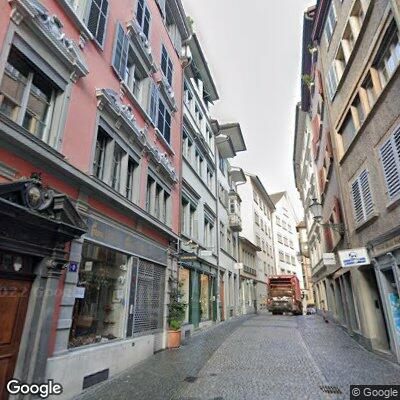


Discovery map saved to: /Users/lukemarinos/WORK/glassscan/data/geometry_single_building_panos.html
Map legend: green camera = viable, purple = CAoS, amber = inside, orange = too close to wall, grey = too far, red = LOS blocked, cyan = slither


In [12]:
# Cell 11b - Visualise viable + rejected panos with actual Street View images.
#
# Debug visualization. For every pano cell 11 discovered (viable or
# rejected for any reason), fetch a Street View image and show it
# side-by-side with the rejection reason and global index #N (matching
# the map labels in cell 11s saved HTML).
#
# Layout: viable first (green border), then each rejection category in
# its own colored section. Image titles include the #N global index so
# you can find any specific pano on the cell-11 map by hovering its
# numbered label.
#
# Cost: each image fetch costs $0.007 (Street View Static API). Cached
# on disk after first fetch, so re-runs are free.
#
# Why bother with rejected images: visual verification of each filter.
# If a "too close" image clearly shows a usable view, the filter was
# over-aggressive. If an "inside building" image looks fine, our 2D
# inside-polygon test misclassified.

import base64

import requests
from IPython.display import HTML, display

from glassscan.fetch.fetch import DEFAULT_FOV, DEFAULT_PITCH

IMG_CACHE_DIR = DATA_DIR / "discovery_debug_images"
IMG_CACHE_DIR.mkdir(parents=True, exist_ok=True)

STREETVIEW_URL = "https://maps.googleapis.com/maps/api/streetview"


def _fetch_pano_image(pano_id, heading, save_path):
    if save_path.exists() and save_path.stat().st_size > 0:
        return save_path
    params = {
        "size": "400x400",
        "pano": pano_id,
        "heading": int(heading),
        "pitch": DEFAULT_PITCH,
        "fov": DEFAULT_FOV,
        "key": GOOGLE_API_KEY,
    }
    r = requests.get(STREETVIEW_URL, params=params, timeout=30)
    if r.status_code != 200 or len(r.content) < 1000:
        return None
    save_path.write_bytes(r.content)
    return save_path


def _img_html(img_path, title, border_color):
    b64 = base64.b64encode(img_path.read_bytes()).decode()
    return (
        '<div style="display:inline-block;margin:4px;'
        f'border:3px solid {border_color};border-radius:6px;padding:4px;'
        'vertical-align:top;">'
        f'<img src="data:image/jpeg;base64,{b64}" '
        'style="width:220px;height:220px;display:block;"/>'
        '<div style="font-size:11px;text-align:center;margin-top:4px;'
        f'max-width:220px;word-wrap:break-word;">{title}</div>'
        '</div>'
    )


# Rejection categories with their colors (must match cell 11s map legend).
REJECTION_GROUPS = [
    ("rejected_user",    rejected_user,    "#6610f2", "user-contributed (CAoS)"),
    ("rejected_inside",  rejected_inside,  "#ffc107", "inside building"),
    ("rejected_close",   rejected_close,   "#fd7e14", "too close to wall"),
    ("rejected_far",     rejected_far,     "#6c757d", "too far from centroid"),
    ("rejected_los",     rejected_los,     "#d62728", "line-of-sight blocked"),
    ("rejected_slither", rejected_slither, "#17a2b8", "slither (small subtense)"),
]

print("Fetching images (cached after first run)...")

# Helper: compute heading toward centroid for any pano
def _heading_to_centroid(pano):
    return _bearing_deg(pano["lat"], pano["lon"], CENTROID_LAT, CENTROID_LON)

# Viable
viable_html = []
for p in panos:
    gi = GLOBAL_IDX_BY_PANO_ID[p["pano_id"]]
    heading = _heading_to_centroid(p)
    img_path = IMG_CACHE_DIR / f"pano_{_sanitize_pano_id(p['pano_id'])}_h{int(heading)}.jpg"
    if _fetch_pano_image(p["pano_id"], heading, img_path) is None:
        continue
    title = (
        f"#{gi} VIABLE<br>"
        f"dist={p['distance_m']:.0f}m, h={p['heading_to_building']:.0f}°<br>"
        f"sees edges {sorted(set(p['found_via_edges']))[:6]}"
    )
    viable_html.append(_img_html(img_path, title, "#28a745"))

# Each rejection group
group_htmls = {}
for name, items, color, label in REJECTION_GROUPS:
    chunk = []
    for r in items:
        gi = GLOBAL_IDX_BY_PANO_ID[r["pano_id"]]
        heading = _heading_to_centroid(r)
        img_path = IMG_CACHE_DIR / f"pano_{_sanitize_pano_id(r['pano_id'])}_h{int(heading)}.jpg"
        if _fetch_pano_image(r["pano_id"], heading, img_path) is None:
            continue
        extras = []
        if "nearest_visible_facade_m" in r:
            extras.append(f"nearest_visible={r['nearest_visible_facade_m']:.1f}m")
        if "building_angular_extent_deg" in r:
            extras.append(f"angular_extent={r['building_angular_extent_deg']:.1f}°")
        title = (
            f"#{gi} {label.upper()}<br>"
            f"dist={r['distance_m']:.0f}m, h={r['heading_to_building']:.0f}°<br>"
            + ("<br>".join(extras) if extras else "")
        )
        chunk.append(_img_html(img_path, title, color))
    group_htmls[name] = chunk

n_total = len(viable_html) + sum(len(v) for v in group_htmls.values())
print(f"Fetched {n_total} images total.")

# Build display
html_parts = ['<div style="font-family:sans-serif;">']
html_parts.append(f'<h3 style="color:#28a745;">Viable ({len(viable_html)})</h3>')
html_parts.append('<div>' + ''.join(viable_html) + '</div>' if viable_html
                  else '<p style="color:#666;font-style:italic;">None.</p>')
for name, items, color, label in REJECTION_GROUPS:
    html_parts.append(f'<h3 style="color:{color};">{label.title()} ({len(group_htmls[name])})</h3>')
    if group_htmls[name]:
        html_parts.append('<div>' + ''.join(group_htmls[name]) + '</div>')
    else:
        html_parts.append('<p style="color:#666;font-style:italic;">None in this category.</p>')
html_parts.append('</div>')

display(HTML(''.join(html_parts)))

# --- Map overlay --------------------------------------------------------
m3 = folium.Map(
    location=[CENTROID_LAT, CENTROID_LON], zoom_start=19, tiles="OpenStreetMap"
)
folium.TileLayer(
    tiles="https://wmts.geo.admin.ch/1.0.0/ch.swisstopo.swissimage/default/current/3857/{z}/{x}/{y}.jpeg",
    attr="(c) swisstopo", name="swissimage (aerial)", overlay=False,
).add_to(m3)

folium.GeoJson(
    footprint_wgs.__geo_interface__,
    style_function=lambda x: {
        "color": "#d33", "weight": 3,
        "fillColor": "#d33", "fillOpacity": 0.20,
    },
).add_to(m3)

for nb in nearby_buildings:
    nb_wgs = shp_transform(lambda x, y, z=None: to_wgs.transform(x, y), nb)
    folium.GeoJson(
        nb_wgs.__geo_interface__,
        style_function=lambda x: {
            "color": "#888", "weight": 1,
            "fillColor": "#888", "fillOpacity": 0.15,
        },
    ).add_to(m3)

def _label_marker(latlon, idx, color):
    """Small numbered DivIcon near a marker, offset so it does not overlap."""
    folium.Marker(
        latlon,
        icon=folium.DivIcon(
            html=(
                '<div style="font-weight:700;background:white;padding:0 3px;'
                f'border:1.5px solid {color};border-radius:3px;font-size:10px;'
                f'white-space:nowrap;">#{idx}</div>'
            ),
            icon_size=(36, 14),
            icon_anchor=(-6, -2),
        ),
    ).add_to(m3)


# Viable: green camera pin + numbered label
for p in panos:
    gi = GLOBAL_IDX_BY_PANO_ID[p["pano_id"]]
    folium.Marker(
        [p["lat"], p["lon"]],
        icon=folium.Icon(color="green", icon="camera", prefix="fa"),
        tooltip=(
            f"#{gi} VIABLE ({p['source']}): dist={p['distance_m']:.1f}m, "
            f"h={p['heading_to_building']:.0f}°, "
            f"sees edges {p['found_via_edges'][:6]}"
        ),
        popup=folium.Popup(
            _make_pano_popup_html(
                p["pano_id"], p["heading_to_building"],
                f"#{gi} VIABLE ({p['source']})", dist_m=p["distance_m"]
            ),
            max_width=280,
        ),
    ).add_to(m3)
    _label_marker([p["lat"], p["lon"]], gi, "#28a745")
    folium.PolyLine(
        [(p["lat"], p["lon"]), (CENTROID_LAT, CENTROID_LON)],
        color="#28a745", weight=1, opacity=0.4, dash_array="3,4",
    ).add_to(m3)

# Rejected variants — different colors per reason.
def _add_rejected(items, color, reason):
    for r in items:
        gi = GLOBAL_IDX_BY_PANO_ID[r["pano_id"]]
        folium.CircleMarker(
            [r["lat"], r["lon"]],
            radius=5, color=color, fill=True, fill_opacity=0.7,
            tooltip=f"#{gi} REJECTED ({reason}): dist={r['distance_m']:.1f}m, src={r['source']}",
            popup=folium.Popup(
                _make_pano_popup_html(
                    r["pano_id"], r["heading_to_building"],
                    f"#{gi} REJECTED ({reason})", dist_m=r["distance_m"]
                ),
                max_width=280,
            ),
        ).add_to(m3)
        _label_marker([r["lat"], r["lon"]], gi, color)

_add_rejected(rejected_user, "#6610f2", "user-contributed (CAoS Trekker)")  # purple
_add_rejected(rejected_inside, "#ffc107", "inside building")  # amber
_add_rejected(rejected_close, "#fd7e14", "too close to target wall")  # orange
_add_rejected(rejected_far, "#6c757d", "too far from building")  # grey
_add_rejected(rejected_los, "#d62728", "line-of-sight blocked")  # red
_add_rejected(rejected_slither, "#17a2b8", "slither view (small angular subtense)")  # cyan

folium.LayerControl().add_to(m3)
PANO_HTML_PATH = DATA_DIR / "geometry_single_building_panos.html"
m3.save(str(PANO_HTML_PATH))
print()
print(f"Discovery map saved to: {PANO_HTML_PATH}")
print(f"Map legend: green camera = viable, purple = CAoS, amber = inside, "
      f"orange = too close to wall, grey = too far, red = LOS blocked, "
      f"cyan = slither")

In [13]:
# Cell 12 - Classify edges per pano; identify VIABLE panos for multi-view.
#
# Design: rather than picking ONE best camera, we evaluate every pano from
# cell 11 and keep those that have at least one geometrically visible
# edge. Cell 13 will fetch one image per viable pano; cell 14+ will
# project + rectify each, and hand the resulting per-view masks to
# aggregate_wwr (which already weights primary=1.0 / secondary=0.5 by
# default and supports LLM-scored weights.json for quality refinement).
#
# Why no single "best" pick:
#   - The geometric pre-filter (visible edges > 0) is a NECESSARY but not
#     SUFFICIENT condition. Geometry can rule out back-of-building or
#     out-of-FOV cameras, but cant detect occlusion (scaffolding, parked
#     trucks, trees in the way), blur, exposure, etc.
#   - Those failure modes are exactly what the existing LLM-scoring step
#     in run.py was built for. Duplicating its job here would be redundant.
#   - Different panos see different facades (south vs east). Aggregating
#     all viable views gives whole-building WWR, not just one walls.
#
# Per-pano edge classification:
#   FACING  - dot(outward_normal, to_camera) > 0
#   IN_FOV  - bearing camera->edge within +/- DEFAULT_FOV/2 of camera heading
#   VISIBLE - both
#
# A pano is VIABLE if it has >=1 visible edge. No distance filter is
# applied: too-close cases will naturally appear as 0 visible edges
# (FOV cone too narrow to cover any facade) and get auto-rejected.
#
# Map colour key:
#   - Coloured cones + circles  - viable panos (each its own colour)
#   - Red dots                  - REJECTED panos (0 visible edges)
#   - Grey edge polylines       - never visible from any pano
#   - Green edge polylines      - visible from at least one pano
#   - Red dot at building       - centroid
#
# Caveat about pano discovery (NOT fixed here): fetch.find_nearby_panoramas
# probes ONE road only (the one perpendicular to the nearest panos
# building bearing) for +/- 45 m (n_steps=3, step_m=15). Cross-street
# coverage and farther-out panos along the same street get missed. If you
# expect specific panos to appear on the map and they dont, the discovery
# step is the place to look, not this cell.

import math
import folium

def _classify_edges_for_pano(pano: dict) -> list[dict]:
    cam_e, cam_n = to_lv95.transform(pano["lon"], pano["lat"])
    cam_heading = pano["heading_to_building"]
    half_fov = DEFAULT_FOV / 2.0
    out = []
    for e in edges:
        mx, my = e["mid_lv95"]
        nx, ny = e["normal_lv95"]
        dE, dN = mx - cam_e, my - cam_n
        dist = math.hypot(dE, dN)
        if dist < 1e-6:
            continue
        to_cam_x, to_cam_y = -dE / dist, -dN / dist
        facing_dot = nx * to_cam_x + ny * to_cam_y
        is_facing = facing_dot > 0
        bearing_to_target = (math.degrees(math.atan2(dE, dN)) + 360) % 360
        angle_off_axis = ((bearing_to_target - cam_heading + 540) % 360) - 180
        in_fov = abs(angle_off_axis) <= half_fov
        out.append({
            **e,
            "facing_dot": facing_dot,
            "is_facing": is_facing,
            "in_fov": in_fov,
            "is_visible": is_facing and in_fov,
            "angle_off_axis": angle_off_axis,
            "dist_to_cam_m": dist,
        })
    return out


def _rejection_reason(cls: list[dict]) -> str:
    n_facing = sum(1 for c in cls if c["is_facing"])
    n_in_fov = sum(1 for c in cls if c["in_fov"])
    if n_facing == 0 and n_in_fov == 0:
        return "no relevant edges"
    if n_facing > 0 and n_in_fov == 0:
        return f"too close: {n_facing} facing edges all outside FOV cone"
    if n_facing == 0 and n_in_fov > 0:
        return f"wrong side: {n_in_fov} in-FOV edges all back-facing"
    return f"{n_facing} facing, {n_in_fov} in_fov, none overlap"


print(f"Per-pano edge classification (FOV={DEFAULT_FOV} deg):")
print(
    f"  {'idx':>3}  {'dist_m':>7}  {'heading':>8}  {'facing':>6}  "
    f"{'in_fov':>6}  {'visible':>7}  {'best_dot':>8}"
)

viable_panos: list[dict] = []
rejected_panos: list[dict] = []
for i, p in enumerate(panos):
    cls = _classify_edges_for_pano(p)
    p["_classified_edges"] = cls  # share with cell 13b (avoid recomputation)
    n_facing = sum(1 for c in cls if c["is_facing"])
    n_in_fov = sum(1 for c in cls if c["in_fov"])
    visible = [c for c in cls if c["is_visible"]]
    n_visible = len(visible)
    best_dot = max((c["facing_dot"] for c in visible), default=0.0)
    flag = "OK" if n_visible > 0 else "skip"
    print(
        f"  {i:>3}  {p['distance_m']:>6.1f}m  {p['heading_to_building']:>7.1f}°  "
        f"{n_facing:>6}  {n_in_fov:>6}  {n_visible:>7}  {best_dot:>+8.3f}  [{flag}]"
    )
    if n_visible > 0:
        viable_panos.append({
            **p,
            "pano_idx": i,
            "n_visible": n_visible,
            "visible_edges": sorted(visible, key=lambda x: -x["facing_dot"]),
        })
    else:
        rejected_panos.append({
            **p,
            "pano_idx": i,
            "n_facing": n_facing,
            "n_in_fov": n_in_fov,
            "reason": _rejection_reason(cls),
        })

print()
print(f"{len(viable_panos)} of {len(panos)} panos are geometrically viable (>=1 visible edge).")

if rejected_panos:
    print()
    print("Rejected panos (red on the map):")
    for rp in rejected_panos:
        print(
            f"  pano #{rp['pano_idx']} (dist={rp['distance_m']:.1f}m, "
            f"heading={rp['heading_to_building']:.0f}°): {rp['reason']}"
        )

if not viable_panos:
    raise RuntimeError(
        "No pano has any visible edge - every camera is back-facing or out "
        "of FOV. Could be a too-narrow FOV or a building with no street "
        "frontage. Inspect the map saved by cell 11 to debug."
    )

print()
print("Visible edges per viable pano:")
for vp in viable_panos:
    edge_ids = ", ".join(
        f"#{e['index']} (dot={e['facing_dot']:+.2f})" for e in vp["visible_edges"]
    )
    print(f"  pano #{vp['pano_idx']} (dist={vp['distance_m']:.1f}m): {edge_ids}")

# Per-edge "seen by which panos" map for the visualisation.
seen_by: dict[int, list[int]] = {}
for vp in viable_panos:
    for e in vp["visible_edges"]:
        seen_by.setdefault(e["index"], []).append(vp["pano_idx"])

# --- Map overlay --------------------------------------------------------
m4 = folium.Map(
    location=[CENTROID_LAT, CENTROID_LON], zoom_start=20, tiles="OpenStreetMap"
)
folium.TileLayer(
    tiles="https://wmts.geo.admin.ch/1.0.0/ch.swisstopo.swissimage/default/current/3857/{z}/{x}/{y}.jpeg",
    attr="(c) swisstopo", name="swissimage (aerial)", overlay=False,
).add_to(m4)

folium.GeoJson(
    footprint_wgs.__geo_interface__,
    style_function=lambda x: {
        "color": "#888", "weight": 1,
        "fillColor": "#888", "fillOpacity": 0.0,
    },
).add_to(m4)

# Edges: green if seen by any pano, grey otherwise.
for e in edges:
    p1_lon, p1_lat = to_wgs.transform(*e["p1_lv95"])
    p2_lon, p2_lat = to_wgs.transform(*e["p2_lv95"])
    seers = seen_by.get(e["index"], [])
    color = "#28a745" if seers else "#bbb"
    weight = 4 if seers else 2
    folium.PolyLine(
        [(p1_lat, p1_lon), (p2_lat, p2_lon)],
        color=color, weight=weight, opacity=0.85,
        tooltip=(
            f"edge {e['index']}: len={e['length_m']:.1f}m, "
            f"bearing={e['bearing_deg']:.0f}°, "
            f"seen by panos: {seers if seers else 'none'}"
        ),
    ).add_to(m4)
    if seers:
        mid_lon, mid_lat = to_wgs.transform(*e["mid_lv95"])
        folium.Marker(
            [mid_lat, mid_lon],
            icon=folium.DivIcon(
                html=(
                    f"<div style='font-weight:700;background:white;"
                    f"padding:0 4px;border:1px solid #28a745;"
                    f"border-radius:3px;font-size:10px;'>{e['index']}</div>"
                ),
                icon_size=(20, 14), icon_anchor=(10, 7),
            ),
        ).add_to(m4)

# Centroid marker.
folium.CircleMarker(
    [CENTROID_LAT, CENTROID_LON],
    radius=4, color="#d33", fill=True, fill_opacity=1.0,
    tooltip="Building centroid",
).add_to(m4)

# Viable panos: coloured cone + circle.
PALETTE = ["#1f77b4", "#ff7f0e", "#2ca02c", "#9467bd", "#8c564b", "#e377c2", "#17becf"]
half_fov = DEFAULT_FOV / 2.0
for vp in viable_panos:
    pano_color = PALETTE[vp["pano_idx"] % len(PALETTE)]
    cone_len_m = max(40.0, vp["distance_m"] * 1.5)
    left_lat, left_lon = _offset_latlon(
        vp["lat"], vp["lon"], vp["heading_to_building"] - half_fov, cone_len_m
    )
    right_lat, right_lon = _offset_latlon(
        vp["lat"], vp["lon"], vp["heading_to_building"] + half_fov, cone_len_m
    )
    folium.Polygon(
        locations=[(vp["lat"], vp["lon"]), (left_lat, left_lon), (right_lat, right_lon)],
        color=pano_color, weight=1, fill=True,
        fill_color=pano_color, fill_opacity=0.10,
        tooltip=f"VIABLE pano #{vp['pano_idx']}: {vp['n_visible']} visible edge(s)",
    ).add_to(m4)
    folium.CircleMarker(
        [vp["lat"], vp["lon"]],
        radius=8, color=pano_color, fill=True, fill_opacity=0.9,
        tooltip=(
            f"VIABLE pano #{vp['pano_idx']}, dist={vp['distance_m']:.1f}m, "
            f"heading={vp['heading_to_building']:.0f}°, "
            f"visible edges: {[e['index'] for e in vp['visible_edges']]}"
        ),
        popup=folium.Popup(
            _make_pano_popup_html(
                vp["pano_id"], vp["heading_to_building"],
                f"VIABLE pano #{vp['pano_idx']}", dist_m=vp["distance_m"]
            ),
            max_width=280,
        ),
    ).add_to(m4)

# Rejected panos: bright red so we can SEE them and debug discovery / FOV.
for rp in rejected_panos:
    folium.CircleMarker(
        [rp["lat"], rp["lon"]],
        radius=8, color="#d62728", fill=True, fill_opacity=0.85,
        tooltip=(
            f"REJECTED pano #{rp['pano_idx']} dist={rp['distance_m']:.1f}m, "
            f"heading={rp['heading_to_building']:.0f}°<br>"
            f"reason: {rp['reason']}"
        ),
        popup=folium.Popup(
            _make_pano_popup_html(
                rp["pano_id"], rp["heading_to_building"],
                f"REJECTED pano #{rp['pano_idx']}", dist_m=rp["distance_m"]
            ),
            max_width=280,
        ),
    ).add_to(m4)
    # Faint dashed view ray so we can see WHERE the rejected camera was aiming.
    tip_lat, tip_lon = _offset_latlon(
        rp["lat"], rp["lon"], rp["heading_to_building"], 25.0
    )
    folium.PolyLine(
        [(rp["lat"], rp["lon"]), (tip_lat, tip_lon)],
        color="#d62728", weight=1, opacity=0.6, dash_array="3,4",
    ).add_to(m4)

folium.LayerControl().add_to(m4)
VISIBILITY_HTML_PATH = DATA_DIR / "geometry_single_building_visibility.html"
m4.save(str(VISIBILITY_HTML_PATH))
print()
print(f"Visibility map saved to: {VISIBILITY_HTML_PATH}")
print(f"Open in browser:         file://{VISIBILITY_HTML_PATH}")

Per-pano edge classification (FOV=70 deg):
  idx   dist_m   heading  facing  in_fov  visible  best_dot
    0     6.5m    225.5°      21      46       18    +0.971  [OK]
    1     7.2m     73.7°      32      57       29    +1.000  [OK]
    2     7.9m     53.1°      35      61       32    +0.999  [OK]
    3    15.3m    159.3°      20      55       16    +0.985  [OK]
    4    17.1m     76.8°      31      64       31    +1.000  [OK]
    5    17.4m    231.9°      21      65       21    +0.971  [OK]
    6    25.0m    163.8°      18      65       18    +0.997  [OK]
    7    27.1m     78.7°      31      65       31    +1.000  [OK]
    8    36.7m    168.8°      16      65       16    +0.999  [OK]
    9    40.4m    157.7°      21      65       21    +0.989  [OK]
   10    43.8m     81.0°      29      65       29    +1.000  [OK]

11 of 11 panos are geometrically viable (>=1 visible edge).

Visible edges per viable pano:
  pano #0 (dist=6.5m): #58 (dot=+0.97), #15 (dot=+0.73), #20 (dot=+0.65), #53 

Building height: 20.62 m
Image: 400x400, FOV=70°, pitch=20°, f=285.6 px

Projecting all visible edges per pano...
  -> 11 panos projected, 23 edges in FOV

Per-pano summary (kept / LOS-visible edges):
  #0  heading=235.6°  4/8 kept (skipped 0 off-FOV, 4 self-occluded): [54, 59, 56, 60]
  #1  heading=75.3°  0/16 kept (skipped 4 off-FOV, 12 self-occluded): []
  #2  heading=51.0°  2/12 kept (skipped 0 off-FOV, 10 self-occluded): [0, 63]
  #3  heading=169.1°  2/10 kept (skipped 0 off-FOV, 8 self-occluded): [59, 60]
  #4  heading=86.6°  1/6 kept (skipped 0 off-FOV, 5 self-occluded): [0]
  #5  heading=244.7°  4/6 kept (skipped 0 off-FOV, 2 self-occluded): [54, 59, 60, 56]
  #6  heading=177.7°  2/7 kept (skipped 0 off-FOV, 5 self-occluded): [59, 60]
  #7  heading=83.9°  1/2 kept (skipped 0 off-FOV, 1 self-occluded): [0]
  #8  heading=181.4°  2/6 kept (skipped 0 off-FOV, 4 self-occluded): [59, 60]
  #9  heading=165.2°  4/8 kept (skipped 0 off-FOV, 4 self-occluded): [60, 59, 63, 0]
  #10  headi


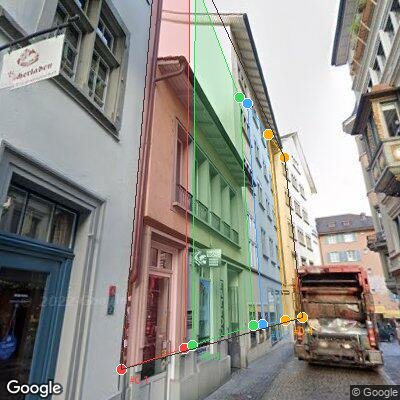
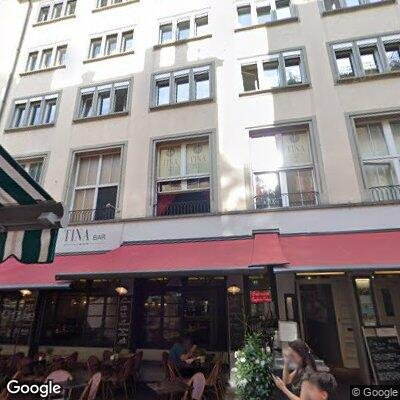
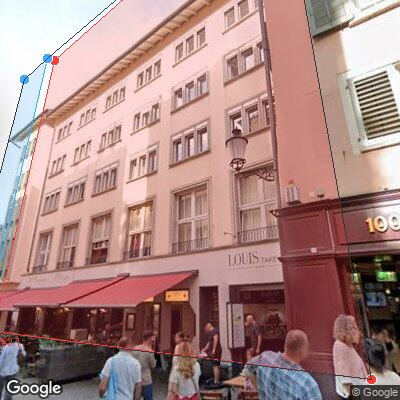
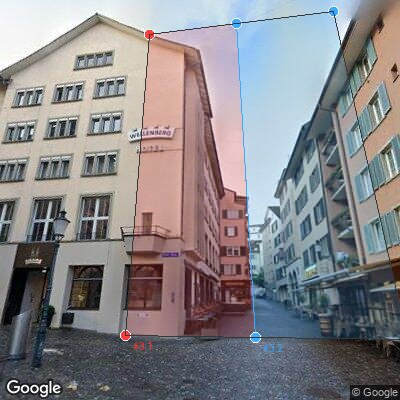
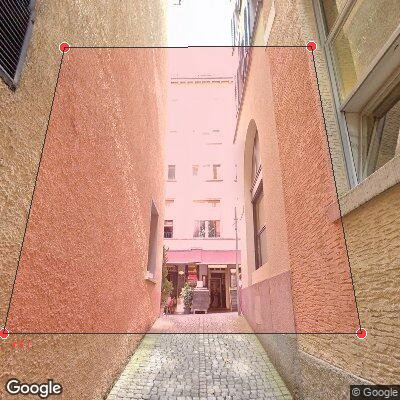
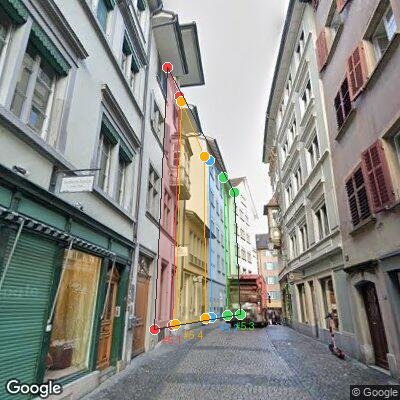
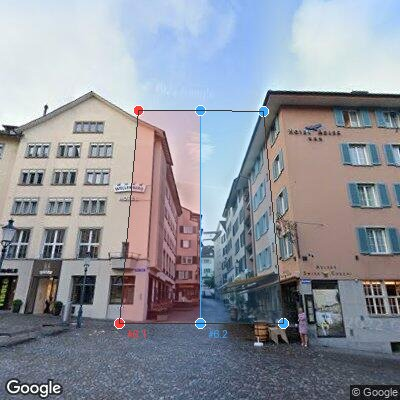
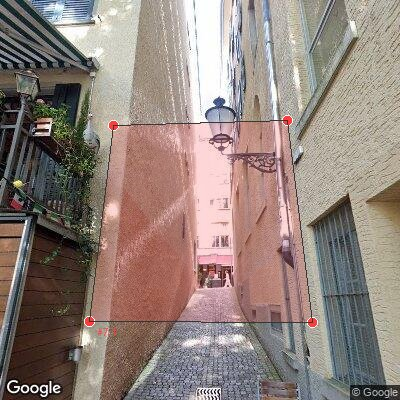
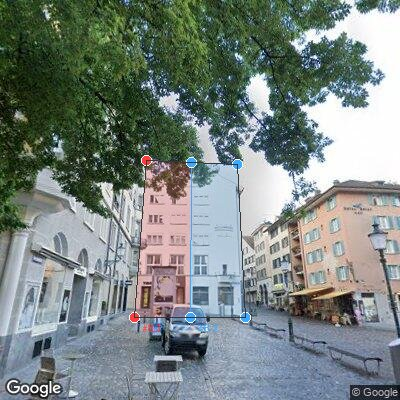
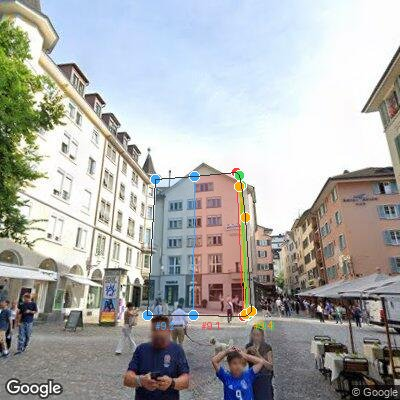
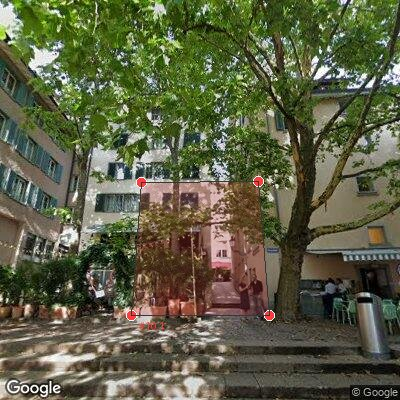


projection_results stored (11 panos x 23 edges total) for cell 14.


In [14]:
# Cell 13 - Project ALL visible facade edges per pano (multi-edge), and
# render each edge's corners on the captured Street View image.
#
# Why multi-edge instead of single best edge:
#
# A typical building footprint has multiple edges that together form what
# a human calls "one wall" (visible from the same vantage point). Picking
# only the most face-on edge and projecting its 4 corners gives:
#   - Wrong horizontal extent (just a slice of the wall, not the whole
#     visible facade).
#   - The chosen edge tends to be the CLOSEST one, where the 21 m height
#     subtends >70° (> our FOV), so the projected top/bottom corners fall
#     OFF the captured image.
# Projecting every visible edge gives the full visible-wall outline, so
# the rectification target in the next cell is the actual usable facade
# the camera caught - not a too-close slice that runs off the image.
#
# THE MATH (same as before, repeated here for completeness):
#
# Pinhole projection: for a 3D world point P and camera (C, R, f):
#   P_cam = R @ (P - C)            # world -> camera frame
#   u = cx + f * P_cam.x / P_cam.z   # behind camera => skip (z <= 0)
#   v = cy + f * P_cam.y / P_cam.z
#
# Coordinate frames:
#   World (LV95+height): x=East, y=North, z=Up
#   Camera (CV):         x=right, y=down, z=forward
#
# Camera rotation R from (heading_deg, pitch_deg):
#   forward = (sin(h)*cos(p), cos(h)*cos(p), sin(p))   # in world
#   right   = forward x world_up                        # x_cam in world
#   down    = forward x right                            # y_cam in world
#   R rows  = [right, down, forward]
#
# Focal length: f = (W/2) / tan(FOV/2)
#
# Per-edge corners: each visible edge contributes 4 corners
# [bottom-near, bottom-far, top-far, top-near] where "near"/"far" is
# determined by which endpoint is on the camera's left vs right (sub-2D
# cross-product test).
#
# Visualisation: each edge's quad gets a distinct colour. We also draw a
# convex hull of ALL projected corners (across edges) - that's the
# rectification-target outline cell 14 will use.

import math
from math import radians, sin, cos, tan, degrees, atan2

import base64
import io

import numpy as np
import requests
from IPython.display import HTML, display
from PIL import Image, ImageDraw

from glassscan.fetch.fetch import DEFAULT_FOV, DEFAULT_PITCH

IMAGE_SIZE = 400
CAMERA_HEIGHT_M = 1.5  # tuned: sidewalk in old Zurich often sits ~1m below GELAENDEPUNKT


def make_camera_rotation(heading_deg, pitch_deg):
    h = radians(heading_deg)
    p = radians(pitch_deg)
    forward = np.array([sin(h) * cos(p), cos(h) * cos(p), sin(p)])
    world_up = np.array([0.0, 0.0, 1.0])
    right = np.cross(forward, world_up)
    right /= np.linalg.norm(right)
    down = np.cross(forward, right)
    down /= np.linalg.norm(down)
    return np.stack([right, down, forward])


def project_point(P, C, R, focal_length, image_size):
    rel = np.asarray(P) - np.asarray(C)
    P_cam = R @ rel
    if P_cam[2] <= 1e-6:
        return None
    cx = image_size / 2.0
    cy = image_size / 2.0
    return (cx + focal_length * P_cam[0] / P_cam[2],
            cy + focal_length * P_cam[1] / P_cam[2])


def edge_corners_camera_relative(edge, height_m, camera_e, camera_n):
    """Return (4, 3) world-space corners ordered for the camera's view:
    [bottom-left, bottom-right, top-right, top-left] where left/right is
    relative to the camera looking toward the edge. Uses a 2D signed-area
    test to decide which endpoint is on the camera's left."""
    p1 = np.array([edge["p1_lv95"][0], edge["p1_lv95"][1]])
    p2 = np.array([edge["p2_lv95"][0], edge["p2_lv95"][1]])
    cam = np.array([camera_e, camera_n])
    # Signed cross-product of (cam->p1) x (cam->p2).
    # Positive => p2 is COUNTER-clockwise from p1 about cam => p2 is on left.
    v1 = p1 - cam
    v2 = p2 - cam
    cross = v1[0] * v2[1] - v1[1] * v2[0]
    # camera's left = larger compass bearing (counter-clockwise sweep).
    # If p2 is on camera's left, BL = p2 (left-bottom), BR = p1.
    if cross > 0:
        bl_xy, br_xy = p2, p1
    else:
        bl_xy, br_xy = p1, p2
    return np.array([
        [bl_xy[0], bl_xy[1], 0.0],
        [br_xy[0], br_xy[1], 0.0],
        [br_xy[0], br_xy[1], height_m],
        [bl_xy[0], bl_xy[1], height_m],
    ])


# Building EAVE height (top of wall, not roof peak).
#
# GESAMTHOEHE = total building height from foundation to highest point
# (roof peak). For a pitched-roof building this includes the entire roof
# slope - way more than the visible wall. The wall we want to rectify
# only goes from ground to where it meets the roof = DACH_MIN.
#
# DACH_MIN is stored in the Roof layer as ABSOLUTE elevation (m above sea
# level). Subtract GELAENDEPUNKT (the building's reference ground
# elevation, also in the Roof / Building_solid layer) to get the height
# of the eave above ground.
#
# For flat-roofed buildings DACH_MIN ~ DACH_MAX so the result is similar
# to using GESAMTHOEHE. For pitched-roof old Zurich buildings (most of
# Niederdorf) the difference is 5-7 m - that's where the projection
# error was coming from.

# Top of building - includes roof peak (so dormer / attic windows are
# inside the rectification target). We use GESAMTHOEHE (foundation to
# highest point) which equals DACH_MAX - GELAENDEPUNKT for buildings with
# both fields populated. Falls back to a Roof-layer query if GESAMTHOEHE
# is missing (e.g. some sacred buildings).
#
# Note: this means projected top corners will go ABOVE the captured image
# when the camera is too close to fit a 21m wall in a 70 deg FOV. The
# homography in cell 14 still works because it only needs corners (in or
# out of image bounds is fine). Adaptive FOV (post-hackathon) would fetch
# wider images so all corners stay on-frame for visualization.

gelaendepunkt = None
for layer_name in ("Building_solid", "Floor", "Wall"):
    if gelaendepunkt is not None:
        break
    with fiona.open(str(GDB_PATH), layer=layer_name) as src:
        for feat in src:
            if str(feat["properties"].get("EGID")) == str(target_egid):
                gelaendepunkt = feat["properties"].get("GELAENDEPUNKT")
                if gelaendepunkt:
                    break

building_height = target_attrs.get("GESAMTHOEHE")
if not building_height or building_height <= 0:
    print("GESAMTHOEHE missing; querying Roof layer for DACH_MAX - GELAENDEPUNKT...")
    with fiona.open(str(GDB_PATH), layer="Roof") as src:
        dach_max = None
        for feat in src:
            if str(feat["properties"].get("EGID")) == str(target_egid):
                d = feat["properties"].get("DACH_MAX")
                if d is not None:
                    dach_max = d if dach_max is None else max(dach_max, d)
    if dach_max is not None and gelaendepunkt is not None:
        building_height = dach_max - gelaendepunkt
        print(f"  -> {dach_max:.2f} - {gelaendepunkt:.2f} = {building_height:.2f} m")
if not building_height or building_height <= 0:
    print("WARNING: building height unknown, defaulting to 15 m")
    building_height = 15.0

# ---------------------------------------------------------------------
# KNOWN LIMITATION: pitched-roof overshoot.
#
# We use GESAMTHOEHE (foundation to roof peak) as the top corner z. For
# flat-roofed buildings this is correct. For PITCHED-roof buildings,
# the peak sits INWARD from the outer footprint edge (typically near
# the roof centerline). At the outer edge the building only reaches
# the EAVE (DACH_MIN), not the peak. Projecting a "top corner" at the
# outer edge with z=GESAMTHOEHE places a point in mid-air above the
# eave - rectified output above the eave is approximate, and
# projection sketches in cell 13b will show top corners shooting
# above the actual roof line by 3-7 m worth of pixel offset for
# typical Zurich pitched-roofs.
#
# Why we accept this: most windows are in the wall (below eave); the
# rectification works on the wall portion. Roof / dormer windows
# above the eave will be poorly rectified but are a small fraction
# of total WWR.
#
# Proper fix (deferred post-hackathon, see CLAUDE.md): use the Wall
# layer's 3D MultiPatch mesh instead of a 4-corner cube approximation.
# ---------------------------------------------------------------------

focal_length = (IMAGE_SIZE / 2.0) / tan(radians(DEFAULT_FOV) / 2.0)
print(f"Building height: {building_height:.2f} m")
print(f"Image: {IMAGE_SIZE}x{IMAGE_SIZE}, FOV={DEFAULT_FOV}°, pitch={DEFAULT_PITCH}°, f={focal_length:.1f} px")
print()

edges_by_idx = {e["index"]: e for e in major_edges}


def heading_to_facade_centroid(pano_e, pano_n, edge_idxs):
    """Compass bearing (deg, 0=N) from camera toward the average midpoint
    of all visible edges - so the camera looks at the centre of the
    visible-wall extent rather than at one specific edge midpoint."""
    if not edge_idxs:
        return 0.0
    mids = np.array([edges_by_idx[i]["mid_lv95"] for i in edge_idxs])
    cx, cy = mids[:, 0].mean(), mids[:, 1].mean()
    dE = cx - pano_e
    dN = cy - pano_n
    return (degrees(atan2(dE, dN)) + 360) % 360


def view_label(global_idx, local_view_idx):
    """Pano-relative view ID: '#N.K' where N=global pano index, K=per-pano sub-index."""
    return f"#{global_idx}.{local_view_idx}"


# Image cache
PROJ_DIR = DATA_DIR / "projection_overlays"
PROJ_DIR.mkdir(parents=True, exist_ok=True)


def _sanitize(s):
    return "".join(c if c.isalnum() or c in "-_" else "_" for c in s)


def fetch_streetview(pano_id, heading, image_size, fov, pitch):
    key = f"pano_{_sanitize(pano_id)}_h{int(heading)}_p{int(pitch)}_f{int(fov)}_s{int(image_size)}.jpg"
    p = PROJ_DIR / key
    if p.exists() and p.stat().st_size > 1000:
        return p
    params = {"size": f"{image_size}x{image_size}", "pano": pano_id,
              "heading": int(heading), "pitch": int(pitch),
              "fov": int(fov), "key": GOOGLE_API_KEY}
    r = requests.get("https://maps.googleapis.com/maps/api/streetview",
                     params=params, timeout=30)
    if r.status_code != 200 or len(r.content) < 1000:
        return None
    p.write_bytes(r.content)
    return p


# ----------------------------------------------------------------------
# Project per (pano, edge) and store everything for cell 14
# ----------------------------------------------------------------------
projection_results = []
print("Projecting all visible edges per pano...")

for p in panos:
    pano_e, pano_n = to_lv95.transform(p["lon"], p["lat"])
    C = np.array([pano_e, pano_n, CAMERA_HEIGHT_M])
    # Camera looks toward the centroid of visible-edge midpoints.
    heading = heading_to_facade_centroid(pano_e, pano_n, p["found_via_edges"])
    R = make_camera_rotation(heading, DEFAULT_PITCH)
    half_fov_deg = DEFAULT_FOV / 2.0
    # facing_dot lookup keyed by edge index (computed in cell 12, stored on p).
    cls_by_idx = {c["index"]: c for c in p["_classified_edges"]}
    edge_quads = []
    skipped_off_fov = 0
    skipped_self_occluded = 0
    for edge_idx in p["found_via_edges"]:
        edge = edges_by_idx[edge_idx]
        # In-FOV filter: skip an edge only if BOTH endpoints sit outside
        # the camera's FOV cone. A partially-visible edge (one endpoint
        # inside the FOV, one outside) genuinely contributes pixels to
        # the captured image, so we keep it - the projected quad may have
        # some off-image corners but the in-FOV portion will render
        # correctly. Midpoint-only check was too aggressive: a long edge
        # whose midpoint lay just outside the FOV cone would be dropped
        # even when one of its endpoints was clearly inside the frame,
        # leaving gaps in the wall coverage.
        mx, my = edge["mid_lv95"]
        p1_e, p1_n = edge["p1_lv95"]
        p2_e, p2_n = edge["p2_lv95"]

        def _off_axis_deg(ept, npt):
            de = ept - pano_e
            dn = npt - pano_n
            b = (degrees(atan2(de, dn)) + 360) % 360
            return abs(((b - heading + 540) % 360) - 180)

        if (_off_axis_deg(p1_e, p1_n) > half_fov_deg
                and _off_axis_deg(p2_e, p2_n) > half_fov_deg):
            skipped_off_fov += 1
            continue
        # Self-occlusion still needs the camera->midpoint ray; recompute
        # dE/dN here so the rest of the loop has them in scope.
        dE_e = mx - pano_e
        dN_e = my - pano_n
        # Self-occlusion: skip if the camera-to-edge ray passes through
        # the target buildings own footprint. Catches back-of-building
        # edges (rays go through the building before reaching the edge)
        # and self-occluded concave cases (L-shapes, wings shielded by
        # other wings). Without this, back walls pass cell 11s LOS test
        # (which only blocks on neighbour buildings, not the target
        # itself) and project to the same image pixels as front walls -
        # producing overlapping quads and degenerate rectifications.
        #
        # NOTE: this is algebra, not raster/pixel scanning. shapely (via
        # GEOS) computes line-segment-vs-polygon-edge intersections
        # analytically: O(N) per call where N is polygon vertex count
        # (~20 after .buffer(0) for our buildings). Microseconds. No
        # pixel sampling involved. `crosses` returns True only when the
        # line passes through the polygons INTERIOR, not when it merely
        # touches the boundary at the edges endpoint - so front-facing
        # edges (line ending on perimeter, no interior penetration) pass
        # while back-facing edges (line crosses interior) get filtered.
        ray = LineString([(pano_e, pano_n), (mx, my)])
        if ray.crosses(target_footprint):
            skipped_self_occluded += 1
            continue
        corners_world = edge_corners_camera_relative(
            edge, building_height, pano_e, pano_n
        )
        image_corners = [project_point(c, C, R, focal_length, IMAGE_SIZE)
                         for c in corners_world]
        edge_quads.append({
            "edge": edge,
            "world_corners": corners_world,
            "image_corners": image_corners,
            "facing_dot": cls_by_idx[edge_idx]["facing_dot"],
        })
    # Sort kept quads by facing_dot desc; assign 1-based local_view_idx.
    # Pano label #N.1 = its most front-on facade, #N.2 = next, etc.
    edge_quads.sort(key=lambda q: -q["facing_dot"])
    for li, lq in enumerate(edge_quads, start=1):
        lq["local_view_idx"] = li
    projection_results.append({
        "global_idx": GLOBAL_IDX_BY_PANO_ID[p["pano_id"]],
        "pano": p,
        "heading": heading,
        "edge_quads": edge_quads,
        "n_los_visible": len(p["found_via_edges"]),
        "n_skipped_off_fov": skipped_off_fov,
        "n_skipped_self_occluded": skipped_self_occluded,
    })

print(f"  -> {len(projection_results)} panos projected, "
      f"{sum(len(r['edge_quads']) for r in projection_results)} edges in FOV")
print()
print("Per-pano summary (kept / LOS-visible edges):")
for r in projection_results:
    print(f"  #{r['global_idx']}  heading={r['heading']:.1f}°  "
          f"{len(r['edge_quads'])}/{r['n_los_visible']} kept "
          f"(skipped {r['n_skipped_off_fov']} off-FOV, "
          f"{r['n_skipped_self_occluded']} self-occluded): "
          f"{[q['edge']['index'] for q in r['edge_quads']]}")

# ----------------------------------------------------------------------
# Render overlays
# ----------------------------------------------------------------------
print()
print("Fetching images and rendering...")

# Distinct colors for up to ~12 edges (cycling).
EDGE_COLORS = [
    (255, 60, 60), (60, 170, 255), (60, 220, 90), (255, 170, 0),
    (200, 60, 220), (255, 120, 180), (0, 200, 200), (180, 100, 60),
    (140, 200, 60), (200, 200, 60), (60, 100, 220), (220, 100, 100),
]


def render_overlay(img_path, projection):
    img = Image.open(img_path).convert("RGB")
    draw = ImageDraw.Draw(img, "RGBA")
    all_pts = []
    for ei, q in enumerate(projection["edge_quads"]):
        col = EDGE_COLORS[ei % len(EDGE_COLORS)]
        col_solid = col + (255,)
        col_fill = col + (50,)
        pts = q["image_corners"]
        valid = [p for p in pts if p is not None]
        all_pts.extend(valid)
        if len(valid) == 4 and all(p is not None for p in pts):
            poly = [(int(p[0]), int(p[1])) for p in pts]
            draw.polygon(poly, outline=col_solid, fill=col_fill)
        elif len(valid) >= 2:
            for a, b in [(0, 1), (1, 2), (2, 3), (3, 0)]:
                if pts[a] is not None and pts[b] is not None:
                    draw.line([(int(pts[a][0]), int(pts[a][1])),
                               (int(pts[b][0]), int(pts[b][1]))],
                              fill=col_solid, width=2)
        for p_uv in valid:
            u, v = p_uv
            r = 5
            draw.ellipse([u - r, v - r, u + r, v + r],
                         fill=col_solid, outline="white", width=1)
        # Pano-relative view label at first valid corner: "#N.K".
        if valid:
            label = view_label(projection["global_idx"], q["local_view_idx"])
            draw.text((int(valid[0][0]) + 8, int(valid[0][1]) + 5),
                      label, fill=col_solid)
    # Convex hull of all projected points - shows the combined rectification target.
    if len(all_pts) >= 3:
        try:
            from scipy.spatial import ConvexHull
            arr = np.array(all_pts)
            hull = ConvexHull(arr)
            hull_pts = [(int(arr[v, 0]), int(arr[v, 1])) for v in hull.vertices]
            draw.polygon(hull_pts, outline=(255, 255, 255, 255))
            draw.polygon(hull_pts, outline=(0, 0, 0, 200))
        except Exception:
            pass
    return img


html_parts = ['<div style="font-family:sans-serif;">']
html_parts.append(
    f'<h3>Multi-edge projection '
    f'(building height = {building_height:.1f} m, FOV = {DEFAULT_FOV}°)</h3>'
)
html_parts.append(
    '<p style="font-size:12px;color:#444;">Each visible edge gets its own '
    'colored quad. The white/black outline is the convex hull of all '
    'projected corners across edges - that\'s what cell 14 will rectify '
    'as the "whole wall". If quads correctly trace the building, the '
    'projection math is right and the rectification target is the visible '
    'wall (not just the closest edge slice).</p>'
)

for r in projection_results:
    img_path = fetch_streetview(
        r["pano"]["pano_id"], r["heading"],
        IMAGE_SIZE, DEFAULT_FOV, DEFAULT_PITCH,
    )
    if img_path is None:
        continue
    img_overlay = render_overlay(img_path, r)
    buf = io.BytesIO()
    img_overlay.save(buf, format="JPEG", quality=85)
    b64 = base64.b64encode(buf.getvalue()).decode()
    title = (f"#{r['global_idx']}  h={r['heading']:.0f}°  "
             f"{len(r['edge_quads'])}/{r['n_los_visible']} edges in FOV")
    html_parts.append(
        '<div style="display:inline-block;margin:6px;border:2px solid #888;'
        'border-radius:6px;padding:6px;vertical-align:top;">'
        f'<img src="data:image/jpeg;base64,{b64}" '
        'style="width:340px;height:340px;display:block;"/>'
        f'<div style="font-size:11px;text-align:center;margin-top:4px;'
        'max-width:340px;">' + title + '</div></div>'
    )
html_parts.append('</div>')
display(HTML(''.join(html_parts)))

print()
print(f"projection_results stored ({len(projection_results)} panos x "
      f"{sum(len(r['edge_quads']) for r in projection_results)} edges total) for cell 14.")


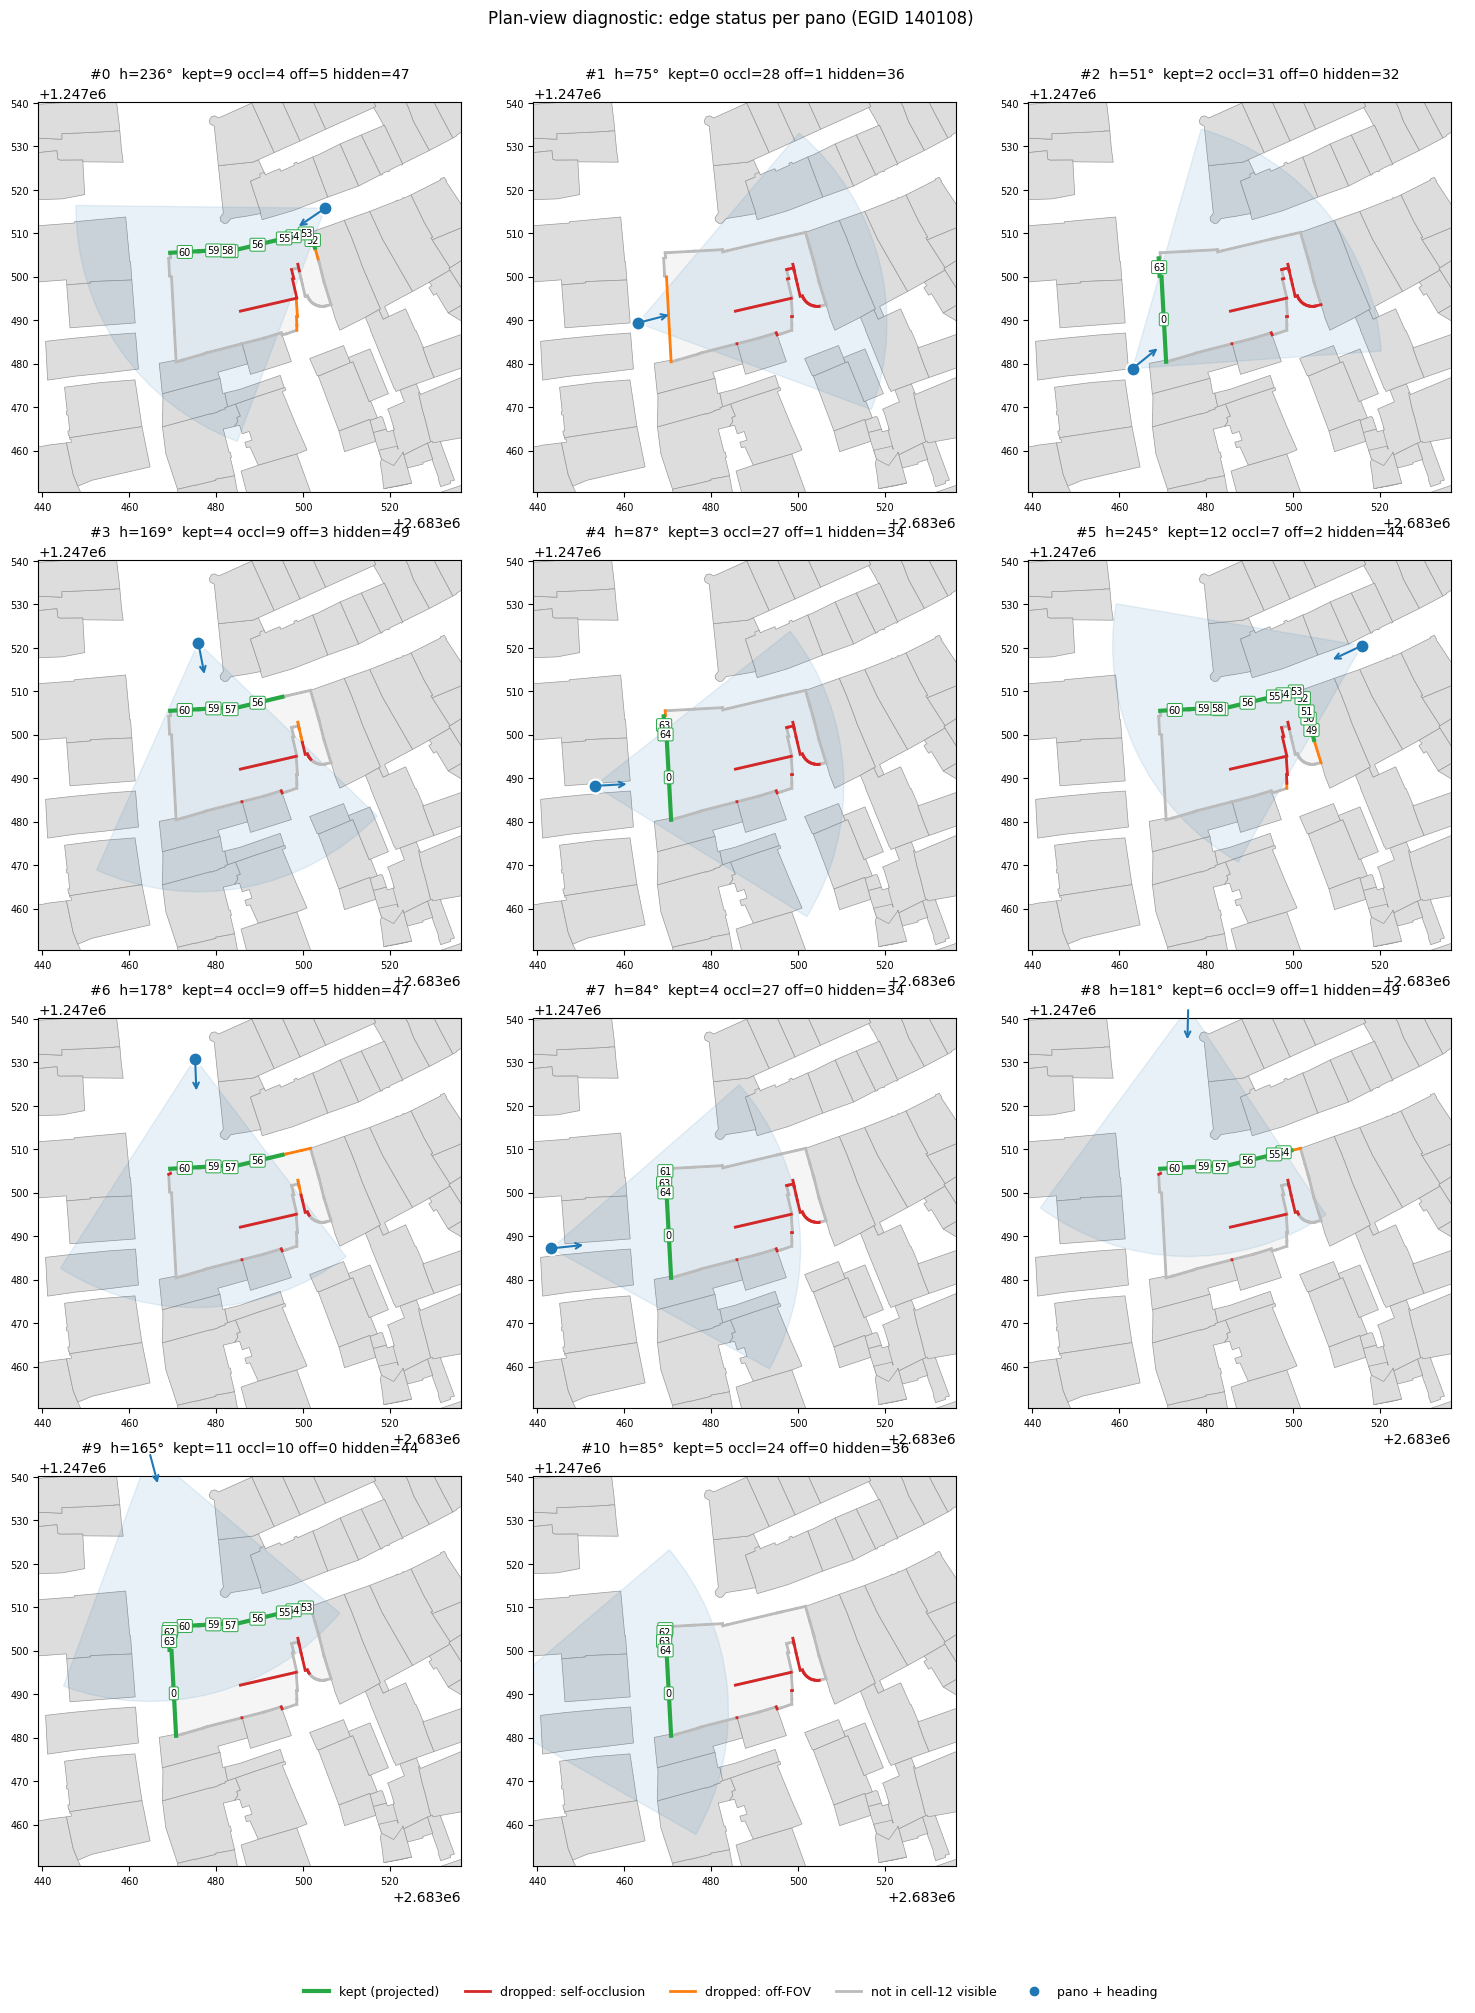

In [15]:
# Cell 13b - Plan-view diagnostic.
#
# Per pano: footprint, neighbours, camera position, FOV cone, and every
# edge coloured by what cell 13 did with it:
#   GREEN  - kept (in projection_results)
#   RED    - cell-12 visible but self-occlusion dropped
#   ORANGE - cell-12 visible but off-FOV dropped
#   GREY   - not in cell 12's visible_edges (back-facing or out of FOV)

import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Wedge
from shapely.geometry import LineString

# Build per-pano edge status: idx -> "kept" | "self_occ" | "off_fov" | "not_visible"
edge_status_by_pano = {}
for r in projection_results:
    p = r["pano"]
    pano_e, pano_n = to_lv95.transform(p["lon"], p["lat"])
    heading = r["heading"]
    half_fov_deg = DEFAULT_FOV / 2.0
    # Reuse cell 12's classification (stored on the pano dict).
    visible_set = {c["index"] for c in p["_classified_edges"] if c["is_visible"]}
    kept_set = {q["edge"]["index"] for q in r["edge_quads"]}

    status = {}
    for e in edges:
        idx = e["index"]
        if idx in kept_set:
            status[idx] = "kept"
            continue
        if idx not in visible_set:
            status[idx] = "not_visible"
            continue
        p1_e, p1_n = e["p1_lv95"]
        p2_e, p2_n = e["p2_lv95"]
        def _off(ept, npt):
            de, dn = ept - pano_e, npt - pano_n
            b = (math.degrees(math.atan2(de, dn)) + 360) % 360
            return abs(((b - heading + 540) % 360) - 180)
        if _off(p1_e, p1_n) > half_fov_deg and _off(p2_e, p2_n) > half_fov_deg:
            status[idx] = "off_fov"
            continue
        mx, my = e["mid_lv95"]
        ray = LineString([(pano_e, pano_n), (mx, my)])
        if ray.crosses(target_footprint):
            status[idx] = "self_occ"
            continue
        status[idx] = "kept"
    edge_status_by_pano[r["global_idx"]] = (pano_e, pano_n, heading, status)

COLORS = {
    "kept": "#28a745",
    "self_occ": "#d62728",
    "off_fov": "#ff7f0e",
    "not_visible": "#bbbbbb",
}

n = len(projection_results)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
axes = np.atleast_2d(axes).flatten()

# MultiPolygon-safe: collect exterior coords from each part.
target_parts = (
    list(target_footprint.geoms)
    if target_footprint.geom_type == "MultiPolygon"
    else [target_footprint]
)
xmin, ymin, xmax, ymax = target_footprint.bounds
pad = 30
xlim = (xmin - pad, xmax + pad)
ylim = (ymin - pad, ymax + pad)

for ax_idx, r in enumerate(projection_results):
    ax = axes[ax_idx]
    gid = r["global_idx"]
    pano_e, pano_n, heading, status = edge_status_by_pano[gid]

    for nb_poly in nearby_buildings:
        for poly in (nb_poly.geoms if nb_poly.geom_type == "MultiPolygon" else [nb_poly]):
            if poly.is_empty:
                continue
            xs = [c[0] for c in poly.exterior.coords]
            ys = [c[1] for c in poly.exterior.coords]
            ax.fill(xs, ys, color="#dddddd", edgecolor="#999", lw=0.5, zorder=1)

    for _part in target_parts:
        xs = [c[0] for c in _part.exterior.coords]
        ys = [c[1] for c in _part.exterior.coords]
        ax.fill(xs, ys, color="#f5f5f5", edgecolor="black", lw=1.0, zorder=2)

    diag = math.hypot(xmax - xmin, ymax - ymin)
    fov_r = diag * 1.2
    half = DEFAULT_FOV / 2.0
    theta_center_math = 90 - heading
    wedge = Wedge(
        (pano_e, pano_n), fov_r,
        theta_center_math - half, theta_center_math + half,
        facecolor="#1f77b4", edgecolor="#1f77b4", alpha=0.10, zorder=2,
    )
    ax.add_patch(wedge)

    for level in ("not_visible", "off_fov", "self_occ", "kept"):
        for e in edges:
            if status[e["index"]] != level:
                continue
            x = [e["p1_lv95"][0], e["p2_lv95"][0]]
            y = [e["p1_lv95"][1], e["p2_lv95"][1]]
            lw = 3.0 if level == "kept" else 2.0
            ax.plot(x, y, color=COLORS[level], lw=lw, zorder=4 if level == "kept" else 3)
            if level == "kept":
                mx, my = e["mid_lv95"]
                ax.text(mx, my, str(e["index"]), fontsize=7,
                        ha="center", va="center", zorder=5,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec=COLORS[level], lw=0.7))

    ax.plot(pano_e, pano_n, "o", color="#1f77b4", ms=10, mec="white", mew=1.5, zorder=6)
    arrow_len = 8.0
    dx = arrow_len * math.sin(math.radians(heading))
    dy = arrow_len * math.cos(math.radians(heading))
    ax.annotate("", xy=(pano_e + dx, pano_n + dy), xytext=(pano_e, pano_n),
                arrowprops=dict(arrowstyle="->", color="#1f77b4", lw=1.5), zorder=7)

    counts = {k: sum(1 for s in status.values() if s == k) for k in COLORS}
    ax.set_title(
        f"#{gid}  h={heading:.0f}°  "
        f"kept={counts['kept']} occl={counts['self_occ']} "
        f"off={counts['off_fov']} hidden={counts['not_visible']}",
        fontsize=10,
    )
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_aspect("equal")
    ax.tick_params(labelsize=7)

for j in range(n, len(axes)):
    axes[j].axis("off")

handles = [
    plt.Line2D([0], [0], color=COLORS["kept"], lw=3, label="kept (projected)"),
    plt.Line2D([0], [0], color=COLORS["self_occ"], lw=2, label="dropped: self-occlusion"),
    plt.Line2D([0], [0], color=COLORS["off_fov"], lw=2, label="dropped: off-FOV"),
    plt.Line2D([0], [0], color=COLORS["not_visible"], lw=2, label="not in cell-12 visible"),
    plt.Line2D([0], [0], marker="o", color="#1f77b4", lw=0, label="pano + heading"),
]
fig.legend(handles=handles, loc="lower center", ncol=5, frameon=False, fontsize=9,
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(f"Plan-view diagnostic: edge status per pano (EGID {target_egid})", fontsize=12)
fig.tight_layout(rect=(0, 0.03, 1, 0.97))
plt.show()


Warping per (pano, edge)...
  -> 23 rectifications.
  -> grouped into 6 facades.

Per-facade view summary (best view starred):
  edge   len_m  n_views  best (view / dot / px / score)
     0    19.5        5  view #4.1 dot=1.00 px= 86449 score=  86288
    54     3.7        2  view #0.1 dot=0.48 px= 17870 score=   8579
    56    11.7        2  view #0.3 dot=0.26 px= 15197 score=   3946
    59     6.5        6  view #3.1 dot=0.99 px= 33409 score=  32922
    60     6.7        6  view #3.2 dot=0.97 px= 40090 score=  38811
    63     4.0        2  view #2.2 dot=0.30 px=  2773 score=    826



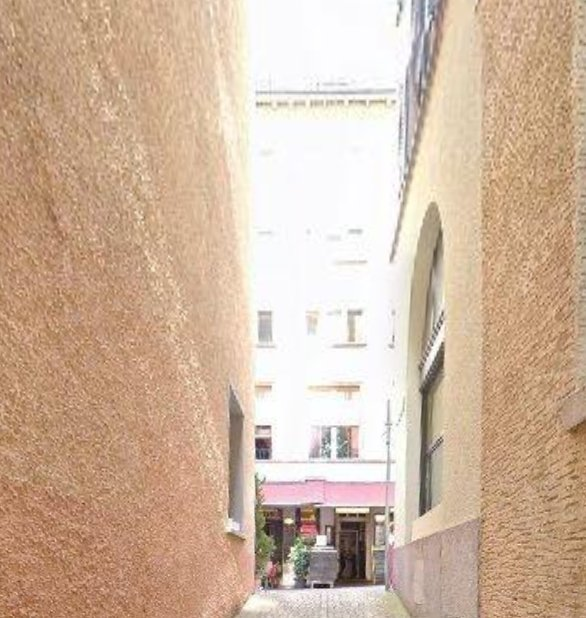
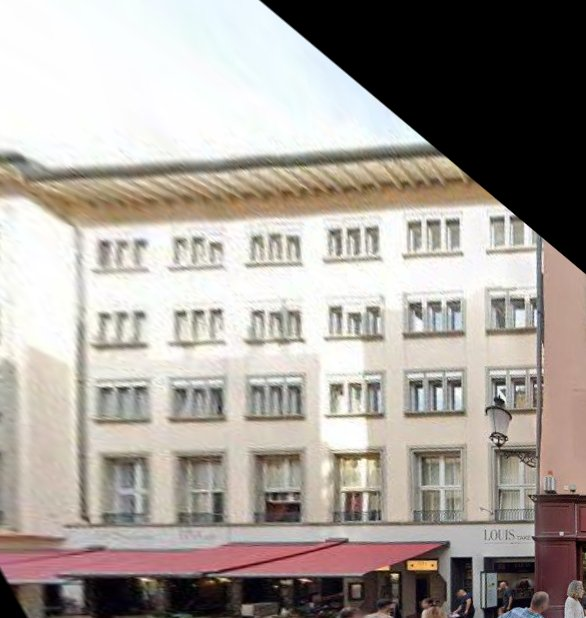
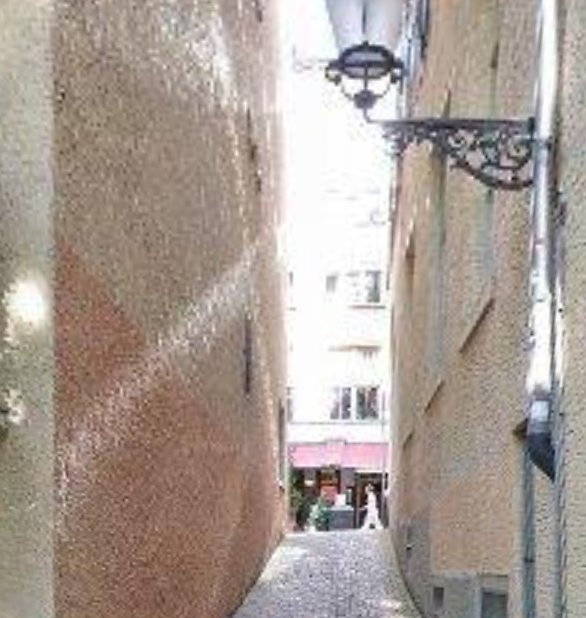
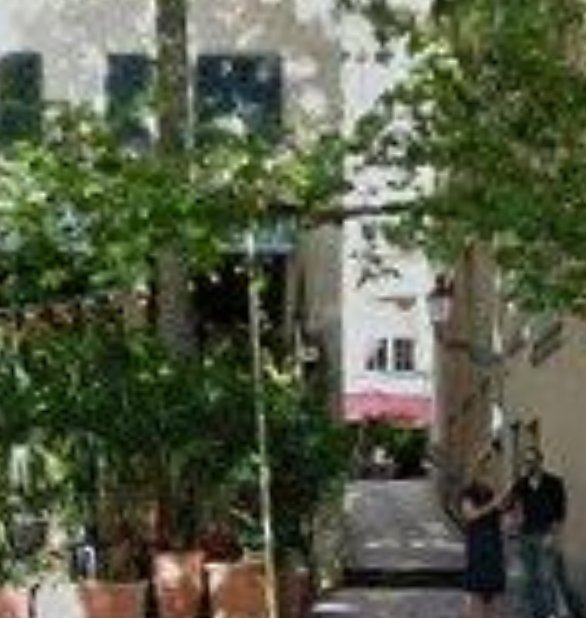
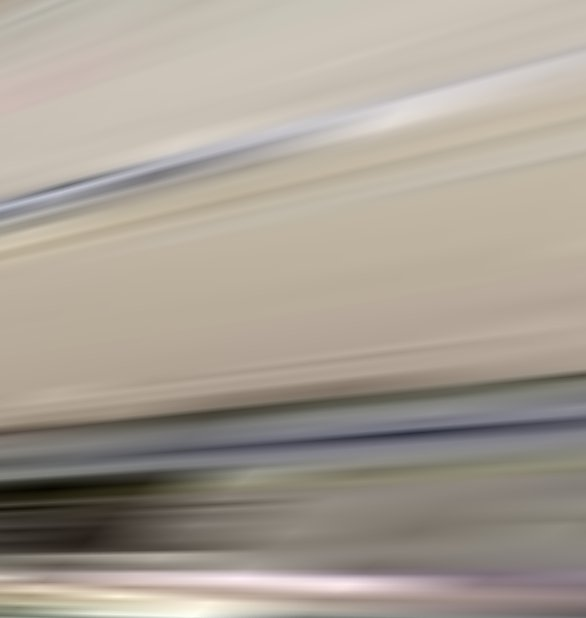
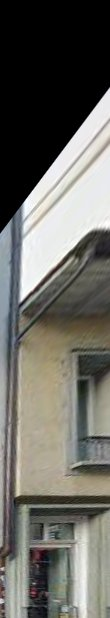
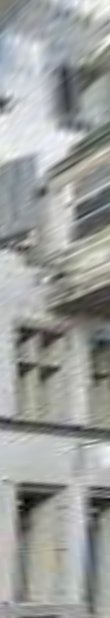
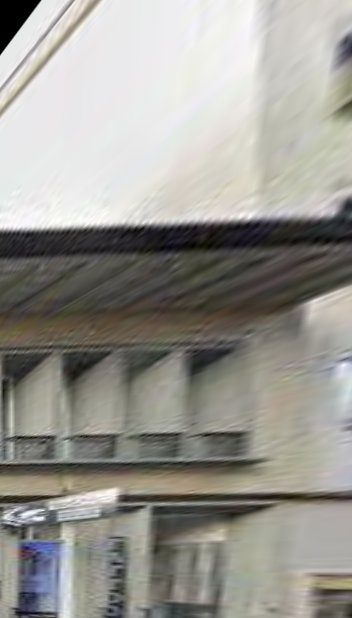
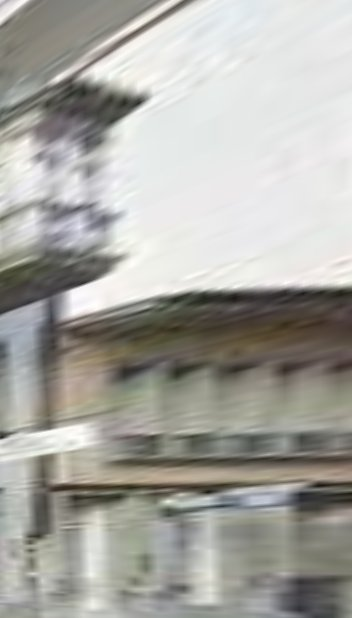
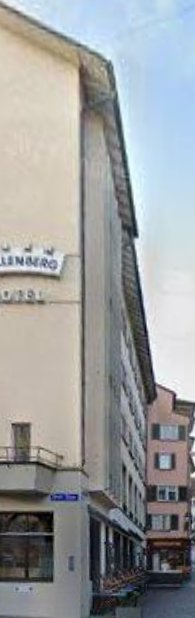
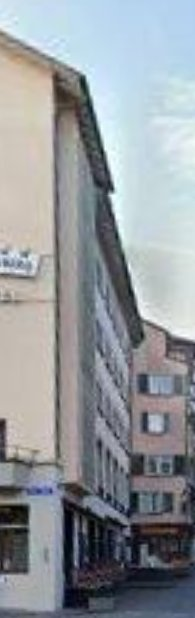
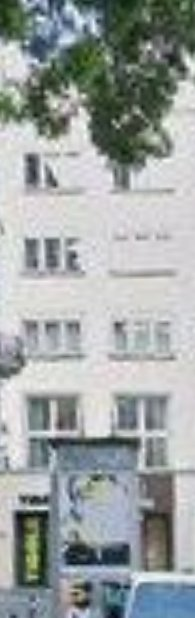
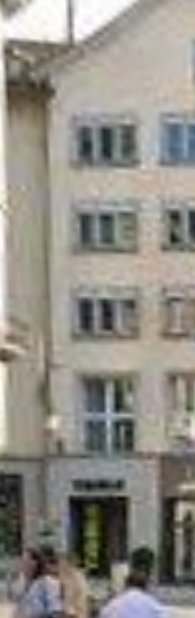
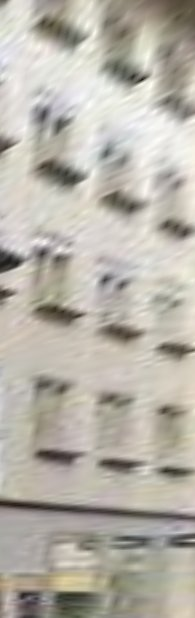
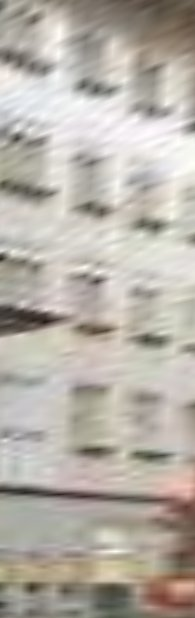
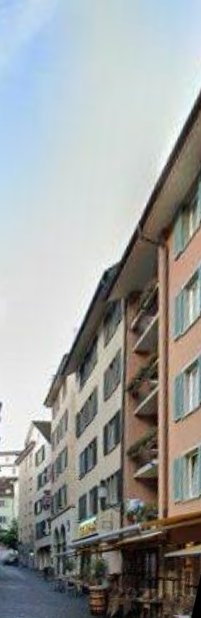
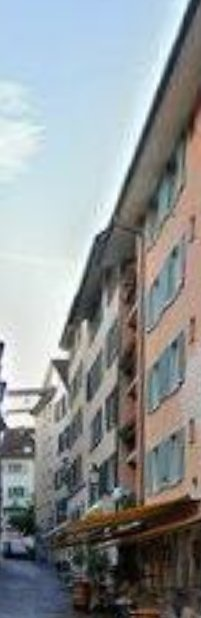
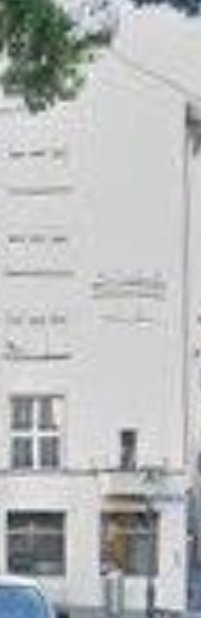
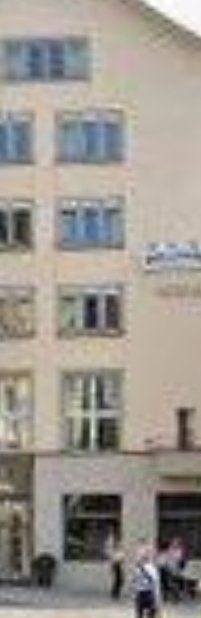
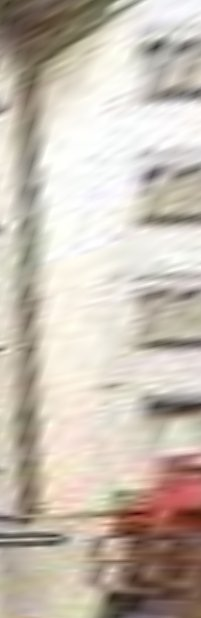
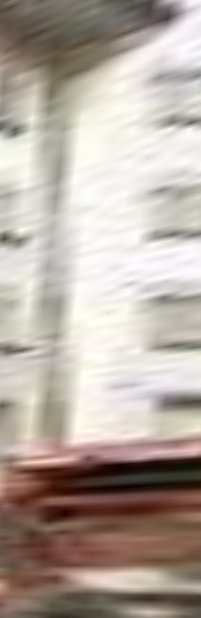
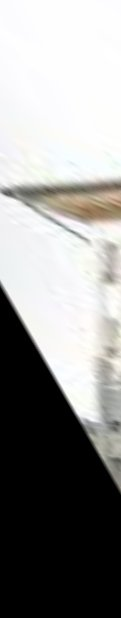
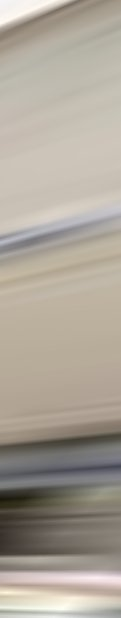


facade_results stored (6 facades, 23 total views) for cell 15+.


In [16]:
# Cell 14 - Per-edge homography + warp; group views by facade; pick best view.
#
# For every (pano, edge_quad) from cell 13:
#   1. 4 image-space corners (src) -> rectangle of edge_length x building_height
#      pixels (dst). One homography per edge per pano via
#      cv2.getPerspectiveTransform.
#   2. Warp the source pano image into the dst rectangle via
#      cv2.warpPerspective. Off-image source coords get filled with black
#      (BORDER_CONSTANT).
#
# Then group all rectifications by their edge index. One facade can be
# captured by multiple panos -> multiple rectified views of the same wall.
# Pick the BEST view per facade by:
#
#   view_score = facing_dot * source_pixel_area
#
# - facing_dot in [0, 1]: 1.0 means the camera is perfectly perpendicular
#   to the facade (homography well-conditioned, minimal distortion). 0.1
#   means grazing angle (degenerate warp).
# - source_pixel_area: shoelace polygon area of the 4 image-space corners.
#   Big quad in the source image = lots of pixels to dewarp = sharper
#   rectified result. Small quad = blocky. Computed for free from the
#   corners we already have.
#
# Multiplying captures both quality dimensions: close+head-on wins
# (highest dot AND most pixels); far+oblique loses (low both).
#
# Output: facade_results = list of {edge_idx, views (sorted by score),
# best_view, edge_length_m, area_m2}. Cell 15+ will segment best_view per
# facade, compute per-facade WWR, then area-weight to building WWR.

from collections import defaultdict

import cv2
import numpy as np

PIXELS_PER_METER = 30  # rectified output scale

def _shoelace_area(pts):
    """Polygon area from 4 (u,v) points. Returns 0 if any corner is None."""
    if any(p is None for p in pts):
        return 0.0
    return abs(sum(
        pts[i][0] * pts[(i + 1) % 4][1] - pts[(i + 1) % 4][0] * pts[i][1]
        for i in range(4)
    )) / 2.0


def _facing_dot(edge, pano_e, pano_n):
    """outward_normal . unit(edge_midpoint -> camera). Range [-1, 1].
    >0 = front-facing; close to 1 = perpendicular to camera."""
    mx, my = edge["mid_lv95"]
    nx, ny = edge["normal_lv95"]
    dE = mx - pano_e
    dN = my - pano_n
    dist = math.hypot(dE, dN)
    if dist < 1e-6:
        return 0.0
    return nx * (-dE / dist) + ny * (-dN / dist)


# ----------------------------------------------------------------------
# Per-quad rectification
# ----------------------------------------------------------------------
all_warps = []
print("Warping per (pano, edge)...")

for pr in projection_results:
    pano_e, pano_n = to_lv95.transform(pr["pano"]["lon"], pr["pano"]["lat"])
    img_path = fetch_streetview(
        pr["pano"]["pano_id"], pr["heading"],
        IMAGE_SIZE, DEFAULT_FOV, DEFAULT_PITCH,
    )
    if img_path is None:
        continue
    src_img = cv2.imread(str(img_path))
    if src_img is None:
        continue

    for q in pr["edge_quads"]:
        edge = q["edge"]
        # Skip if any corner is behind camera (None).
        if any(c is None for c in q["image_corners"]):
            continue
        src_pts = np.array(
            [[c[0], c[1]] for c in q["image_corners"]],
            dtype=np.float32,
        )
        edge_len = edge["length_m"]
        dst_w = max(1, int(edge_len * PIXELS_PER_METER))
        dst_h = max(1, int(building_height * PIXELS_PER_METER))
        # Destination quad: BL, BR, TR, TL with image-y growing downward.
        dst_pts = np.array([
            [0,     dst_h],   # BL
            [dst_w, dst_h],   # BR
            [dst_w, 0],       # TR
            [0,     0],       # TL
        ], dtype=np.float32)

        try:
            H = cv2.getPerspectiveTransform(src_pts, dst_pts)
        except cv2.error:
            # Degenerate corners (collinear, etc.) - skip.
            continue
        rectified = cv2.warpPerspective(
            src_img, H, (dst_w, dst_h),
            flags=cv2.INTER_LINEAR,
            borderMode=cv2.BORDER_CONSTANT,
            borderValue=(0, 0, 0),
        )

        fdot = _facing_dot(edge, pano_e, pano_n)
        # On-frame area: intersect projected quad with the captured-image
        # rectangle so off-frame portions (which become black in the warp
        # output and get dropped by cell 15's segment post-processing) don't
        # inflate the view score.
        from shapely.geometry import Polygon as _SPolygon, box as _sbox
        _quad = _SPolygon([(c[0], c[1]) for c in q["image_corners"]])
        if not _quad.is_valid:
            _quad = _quad.buffer(0)
        px_area = _quad.intersection(_sbox(0, 0, IMAGE_SIZE, IMAGE_SIZE)).area
        score = max(0.0, fdot) * px_area

        all_warps.append({
            "edge_idx": edge["index"],
            "edge_length_m": edge_len,
            "pano_global_idx": pr["global_idx"],
            "local_view_idx": q["local_view_idx"],
            "pano_id": pr["pano"]["pano_id"],
            "facing_dot": fdot,
            "pixel_area": px_area,
            "score": score,
            "rectified": rectified,
            "dst_w": dst_w,
            "dst_h": dst_h,
        })

print(f"  -> {len(all_warps)} rectifications.")

# ----------------------------------------------------------------------
# Group by edge_idx, pick best view per facade
# ----------------------------------------------------------------------
by_edge = defaultdict(list)
for w in all_warps:
    by_edge[w["edge_idx"]].append(w)

facade_results = []
for edge_idx, views in by_edge.items():
    views.sort(key=lambda v: -v["score"])
    facade_results.append({
        "edge_idx": edge_idx,
        "views": views,
        "best_view": views[0],
        "edge_length_m": views[0]["edge_length_m"],
        "area_m2": views[0]["edge_length_m"] * building_height,
    })
facade_results.sort(key=lambda f: f["edge_idx"])

print(f"  -> grouped into {len(facade_results)} facades.")
print()
print("Per-facade view summary (best view starred):")
print(f"  {'edge':>4}  {'len_m':>6}  {'n_views':>7}  best (view / dot / px / score)")
for f in facade_results:
    bv = f["best_view"]
    print(f"  {f['edge_idx']:>4}  {f['edge_length_m']:>6.1f}  "
          f"{len(f['views']):>7}  view {view_label(bv['pano_global_idx'], bv['local_view_idx'])} "
          f"dot={bv['facing_dot']:.2f} px={bv['pixel_area']:>6.0f} "
          f"score={bv['score']:>7.0f}")

# ----------------------------------------------------------------------
# Display: per facade, all views with the best one starred
# ----------------------------------------------------------------------
import base64

html_parts = ['<div style="font-family:sans-serif;">']
html_parts.append('<h3>Rectified facades (best view per edge starred)</h3>')
html_parts.append(
    '<p style="font-size:12px;color:#444;">One row per facade. Green border '
    '= best view (highest facing_dot * source_pixel_area). Black bars in '
    'the rectified image = source pixels were off-frame in the original '
    'capture (typically the roof above the eave because of the pitched-'
    'roof overshoot known limitation).</p>'
)

for f in facade_results:
    html_parts.append(
        f'<h4>Edge #{f["edge_idx"]} '
        f'(length={f["edge_length_m"]:.1f}m, area={f["area_m2"]:.0f}m²)</h4>'
    )
    html_parts.append('<div>')
    for i, v in enumerate(f["views"]):
        is_best = (i == 0)
        ok, jpg_bytes = cv2.imencode('.jpg', v["rectified"], [cv2.IMWRITE_JPEG_QUALITY, 85])
        if not ok:
            continue
        b64 = base64.b64encode(jpg_bytes.tobytes()).decode()
        border_color = "#28a745" if is_best else "#888"
        border_width = 3 if is_best else 1
        max_disp_h = 240
        max_disp_w = max(60, max_disp_h * v["dst_w"] // v["dst_h"])
        star = "★ " if is_best else "  "
        title = (f"{star}{view_label(v['pano_global_idx'], v['local_view_idx'])}  "
                 f"dot={v['facing_dot']:.2f}  "
                 f"px={v['pixel_area']:.0f}  score={v['score']:.0f}")
        html_parts.append(
            f'<div style="display:inline-block;margin:4px;'
            f'border:{border_width}px solid {border_color};border-radius:6px;'
            f'padding:4px;vertical-align:top;">'
            f'<img src="data:image/jpeg;base64,{b64}" '
            f'style="max-height:{max_disp_h}px;width:auto;display:block;"/>'
            f'<div style="font-size:11px;text-align:center;margin-top:4px;'
            f'max-width:{max_disp_w}px;">{title}</div>'
            f'</div>'
        )
    html_parts.append('</div>')

html_parts.append('</div>')
display(HTML(''.join(html_parts)))

print()
print(f"facade_results stored ({len(facade_results)} facades, "
      f"{sum(len(f['views']) for f in facade_results)} total views) for cell 15+.")


/Users/lukemarinos/WORK/glassscan/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading segmentation models (slow on first run, cached after)...
  device: mps


Loading weights: 100%|██████████| 1172/1172 [00:00<00:00, 50493.30it/s]
SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b5-finetuned-ade-640-640
Key                           | Status   |                                                                                                      
------------------------------+----------+------------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([13, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([13])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


  done.

Segmenting per-facade best views...
  edge # 0 (view #4.1): img 586x618px, window=6804px, wall=330941px, bg=24403px (conf=0.91)
  edge #54 (view #0.1): img 110x618px, window=315px, wall=29524px, bg=38141px (conf=0.93)
  edge #56 (view #0.3): img 352x618px, window=2264px, wall=86641px, bg=128631px (conf=0.90)
  edge #59 (view #3.1): img 195x618px, window=3010px, wall=82410px, bg=35090px (conf=0.90)
  edge #60 (view #3.2): img 201x618px, window=10031px, wall=49324px, bg=64863px (conf=0.88)
  edge #63 (view #2.2): img 121x618px, window=0px, wall=0px, bg=74778px (conf=0.99)

Done. Each facade now has a `segmentation` field for cell 16.



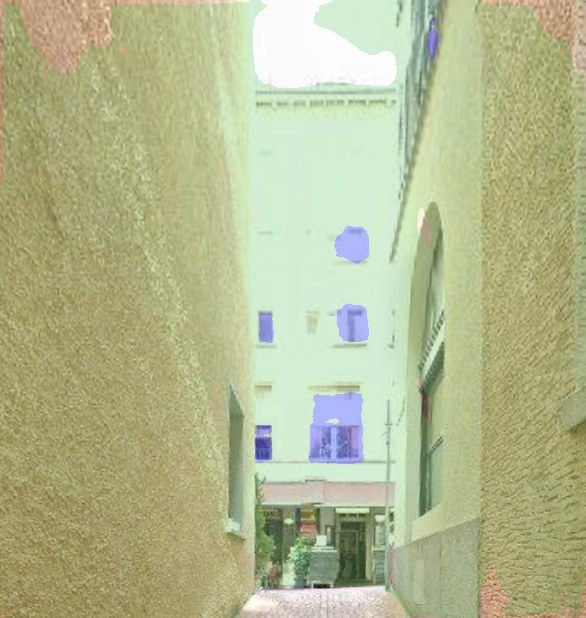
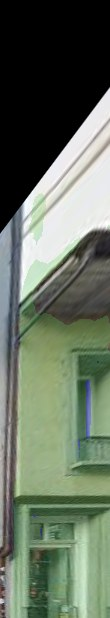
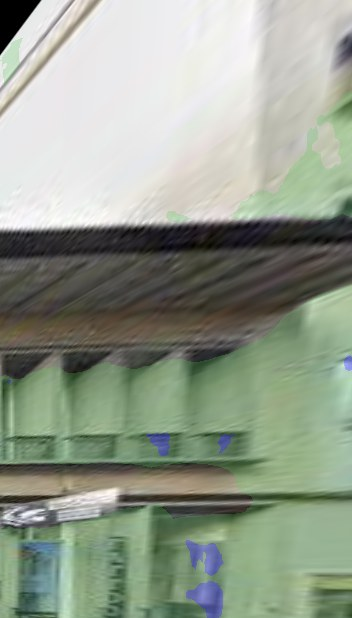
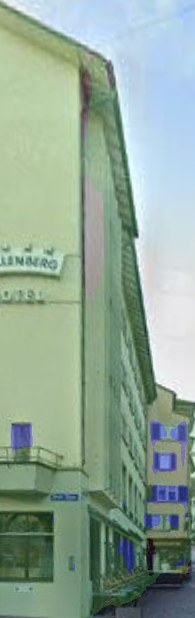
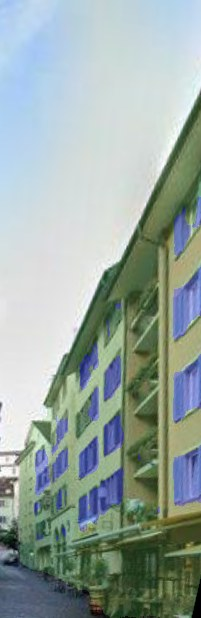
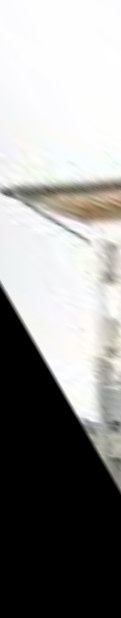

In [17]:
# Cell 15 - Segment each per-facade best rectified view (production model).
#
# We feed each facade's best rectified image through the existing
# two-stage segmentation:
#   Stage 1 (ADE20K): identify "building" pixels in the wider scene.
#   Stage 2 (CMP Facades): classify wall vs window vs door within
#     building pixels. Outputs a 3-class mask: 0=background, 1=wall,
#     2=window.
#
# Note: the CMP Facades model was trained on RECTIFIED facade images
# (cmp.felk.cvut.cz/~tylecr1/facade/), so our rectified output is
# closer to its training distribution than raw Street View captures.
# The ADE20K stage may behave oddly on rectified images (no sky/road
# context, black bars from off-frame source pixels), so as a safety
# step we override segmentation pixels that were BLACK in the source
# (off-frame area) back to background. The WWR computation in cell 16
# only counts wall (1) and window (2), so background pixels are
# correctly ignored.
#
# Heads-up: the first call to load_model downloads ~500 MB of
# HuggingFace weights. Cached after the first run.

import numpy as np

from glassscan.segment.segment import (
    load_model, segment_image, _get_device,
)
from glassscan.types import BuildingImage

# (Production _CMP_REMAP now maps blind and shop to window for energy WWR;
# see segment.py comment. No monkeypatch needed here anymore.)

# ----------------------------------------------------------------------
# Load models once (slow first time; cached afterwards)
# ----------------------------------------------------------------------
print("Loading segmentation models (slow on first run, cached after)...")
device = _get_device()
print(f"  device: {device}")
seg_models = load_model(device=device)
print("  done.")

# ----------------------------------------------------------------------
# Segment each facade's best rectified view
# ----------------------------------------------------------------------

def black_pixel_mask(image_bgr):
    """Bool mask of pixels that are pure black (off-frame source artefact)."""
    return np.all(image_bgr == 0, axis=-1)


print()
print("Segmenting per-facade best views...")
for f in facade_results:
    bv = f["best_view"]
    rectified = bv["rectified"]  # BGR uint8 H x W x 3
    h, w = rectified.shape[:2]

    # Wrap as BuildingImage for the existing segment_image API.
    # Use the actual pano metadata so any cached behaviour keyed on egid
    # is meaningful. view_index = edge_idx (synthetic) so cache files
    # don't collide across facades.
    bi = BuildingImage(
        egid=f"{target_egid}-edge{f['edge_idx']}",
        image=rectified,
        lat=bv["pano_id"] and 0.0,  # not used by segment_image
        lon=0.0,
        heading=0.0,
        pitch=0.0,
        fov=DEFAULT_FOV,
        pano_id=bv["pano_id"],
        view_index=f["edge_idx"],
    )

    seg_result = segment_image(bi, seg_models)

    # Post-process: black pixels (off-frame source) -> background (0).
    blk = black_pixel_mask(rectified)
    seg_result.mask[blk] = 0

    # Counts (after black-bar masking)
    n_window = int(np.sum(seg_result.mask == 2))
    n_wall = int(np.sum(seg_result.mask == 1))
    n_bg = int(np.sum(seg_result.mask == 0))
    total = n_window + n_wall + n_bg
    print(f"  edge #{f['edge_idx']:>2} (view {view_label(bv['pano_global_idx'], bv['local_view_idx'])}): "
          f"img {w}x{h}px, "
          f"window={n_window}px, wall={n_wall}px, bg={n_bg}px "
          f"(conf={seg_result.confidence:.2f})")

    f["segmentation"] = {
        "mask": seg_result.mask,
        "confidence": seg_result.confidence,
        "n_window_px": n_window,
        "n_wall_px": n_wall,
        "n_background_px": n_bg,
        "image_w": w,
        "image_h": h,
    }

print()
print("Done. Each facade now has a `segmentation` field for cell 16.")

# ----------------------------------------------------------------------
# Display: rectified | mask side-by-side per facade
# ----------------------------------------------------------------------
import base64
import cv2

def overlay_mask(rectified_bgr, mask, alpha_window=0.40, alpha_wall=0.25):
    """Translucent overlay: windows tinted blue, walls tinted green.
    Background pixels left untouched (so missing-from-mask regions stay
    visually distinct, e.g. ADE20K-filtered or off-frame black bars).
    Returns BGR uint8 image with overlay applied."""
    out = rectified_bgr.copy().astype(np.float32)
    win_color = np.array([255, 80, 60], dtype=np.float32)    # BGR: blue
    wall_color = np.array([90, 200, 90], dtype=np.float32)   # BGR: green
    if alpha_window > 0:
        win = mask == 2
        out[win] = out[win] * (1 - alpha_window) + win_color * alpha_window
    if alpha_wall > 0:
        wall = mask == 1
        out[wall] = out[wall] * (1 - alpha_wall) + wall_color * alpha_wall
    return out.clip(0, 255).astype(np.uint8)


html_parts = ['<div style="font-family:sans-serif;">']
html_parts.append('<h3>Segmented facades (windows highlighted)</h3>')
html_parts.append(
    '<p style="font-size:12px;color:#444;">Blue tint = pixels classified as '
    'window (counted in WWR numerator). Green tint = pixels classified as '
    'wall (counted in WWR denominator). Untinted = background (off-frame '
    'black bars or non-facade pixels filtered by ADE20K - NOT counted in '
    'WWR at all). The WWR denominator (window+wall pixels) should cover '
    'most of the actual building wall in the photo; if large portions of '
    'real wall are untinted, the model is misclassifying them and the WWR '
    'ratio is computed over a smaller-than-true facade.</p>'
)

for f in facade_results:
    seg = f["segmentation"]
    bv = f["best_view"]
    rect = bv["rectified"]
    overlay_img = overlay_mask(rect, seg["mask"])

    ok, jpg = cv2.imencode('.jpg', overlay_img, [cv2.IMWRITE_JPEG_QUALITY, 88])
    if not ok:
        continue
    b64 = base64.b64encode(jpg.tobytes()).decode()

    facade_pct_window = (seg["n_window_px"]
                         / max(1, seg["n_window_px"] + seg["n_wall_px"])) * 100
    title = (f"<b>Edge #{f['edge_idx']} · view {view_label(bv['pano_global_idx'], bv['local_view_idx'])}</b>  "
             f"area={f['area_m2']:.0f}m²  ·  "
             f"conf={seg['confidence']:.2f}  ·  "
             f"WWR (this view) = {facade_pct_window:.1f}%<br>"
             f"<span style='color:#3070ff'>window={seg['n_window_px']}px</span>  ·  "
             f"<span style='color:#2a8b2a'>wall={seg['n_wall_px']}px</span>  ·  "
             f"<span style='color:#888'>bg={seg['n_background_px']}px</span>")
    max_disp_h = 320
    html_parts.append(
        '<div style="display:inline-block;margin:6px;border:1px solid #888;'
        'border-radius:6px;padding:6px;vertical-align:top;">'
        f'<img src="data:image/jpeg;base64,{b64}" '
        f'style="max-height:{max_disp_h}px;display:block;"/>'
        f'<div style="font-size:11px;text-align:center;margin-top:4px;'
        'max-width:400px;">' + title + '</div>'
        '</div>'
    )
html_parts.append('</div>')
display(HTML(''.join(html_parts)))


In [18]:
# Cell 16 - Per-facade WWR + score x area-weighted building WWR.
#
# Pipeline:
#   1. Per facade, take the best view's segmentation. Compute
#         wwr_facade = n_window / (n_window + n_wall)
#      "Background" pixels (off-frame black bars or anything ADE20K
#      filtered as non-building) are excluded from both sides of the
#      ratio - they aren't real wall and aren't real window.
#   2. Skip any facade with zero valid pixels (n_window + n_wall == 0).
#      Typically the grazing-angle views with mostly background.
#   3. Weight each facade by view_score * area_m2:
#        view_score = facing_dot * source_pixel_area  (set in cell 14)
#        area_m2    = edge_length_m * building_height (set in cell 14)
#      The score factor down-weights low-confidence views (grazing,
#      tiny source pixel area). The area factor scales each facade by
#      its real-world contribution to the building's exterior surface.
#   4. Building WWR = sum(weight_i * wwr_i) / sum(weight_i).
#
# Failure modes:
#   - All facades skipped (no facade has any wall+window pixels) -> raise
#     RuntimeError. This is the notebook's loud-failure mode for
#     single-building debugging. Production aggregation should switch
#     to NaN + warning instead so one broken building doesn't abort a
#     batch (CLAUDE.md tracks this).
#
# Output: prints the per-facade table + building WWR + side-by-side
# comparison to run.py's WWR for the same EGID (read from
# src/glassscan/visualise/dashboard/public/buildings.json).

# ----------------------------------------------------------------------
# Per-facade WWR
# ----------------------------------------------------------------------
print("Per-facade WWR (best view per facade):")
print(f"  {'edge':>4}  {'view':>7}  {'len':>5}  {'area':>5}  {'score':>7}  "
      f"{'win_px':>7}  {'wall_px':>7}  {'WWR':>6}  {'weight':>8}")

facade_wwrs = []
for f in facade_results:
    seg = f.get("segmentation")
    if seg is None:
        continue
    n_w = seg["n_window_px"]
    n_a = seg["n_wall_px"]
    valid = n_w + n_a
    bv = f["best_view"]
    vlabel = view_label(bv["pano_global_idx"], bv["local_view_idx"])
    if valid == 0:
        # Skip facades with no useable pixels (e.g. grazing views).
        print(f"  {f['edge_idx']:>4}  {vlabel:>7}  {f['edge_length_m']:>5.1f}  "
              f"{f['area_m2']:>5.0f}  -        skipped (no wall+window pixels)")
        continue
    wwr = n_w / valid
    weight = bv["score"] * f["area_m2"]
    facade_wwrs.append({
        "edge_idx": f["edge_idx"],
        "pano_global_idx": bv["pano_global_idx"],
        "local_view_idx": bv["local_view_idx"],
        "wwr": wwr,
        "weight": weight,
        "n_window_px": n_w,
        "n_wall_px": n_a,
        "area_m2": f["area_m2"],
        "view_score": bv["score"],
    })
    print(f"  {f['edge_idx']:>4}  {vlabel:>7}  {f['edge_length_m']:>5.1f}  "
          f"{f['area_m2']:>5.0f}  {bv['score']:>7.0f}  "
          f"{n_w:>7}  {n_a:>7}  {wwr:>5.1%}  {weight:>8.0f}")

# ----------------------------------------------------------------------
# Catastrophic-failure guard
# ----------------------------------------------------------------------
if not facade_wwrs:
    raise RuntimeError(
        f"All {len(facade_results)} facades dropped (no wall+window pixels "
        "in any best view). Check upstream: rectification might be producing "
        "all-black images, or segmentation might be classifying everything "
        "as background. Inspect cell 15's overlays."
    )

total_weight = sum(f["weight"] for f in facade_wwrs)
if total_weight <= 0:
    raise RuntimeError(
        f"All {len(facade_wwrs)} surviving facades have zero weight "
        "(view_score * area_m2). Check that view scores in cell 14 are not "
        "all zero, and that area_m2 is non-zero (building height resolved "
        "correctly in cell 13)."
    )

# ----------------------------------------------------------------------
# Score x area-weighted building WWR
# ----------------------------------------------------------------------
building_wwr = sum(f["weight"] * f["wwr"] for f in facade_wwrs) / total_weight

print()
print("Per-facade contribution to building WWR:")
print(f"  {'edge':>4}  {'view':>7}  {'WWR':>6}  {'weight':>8}  {'weight%':>7}  "
      f"{'contribution':>12}")
for f in sorted(facade_wwrs, key=lambda x: -x["weight"]):
    pct = f["weight"] / total_weight * 100
    contrib = f["weight"] * f["wwr"] / total_weight
    vlabel = view_label(f["pano_global_idx"], f["local_view_idx"])
    print(f"  {f['edge_idx']:>4}  {vlabel:>7}  {f['wwr']:>5.1%}  {f['weight']:>8.0f}  "
          f"{pct:>6.1f}%  {contrib:>11.3f}")

print()
print(f"=" * 50)
print(f"  Building WWR (geometry pipeline) = {building_wwr:.3f} ({building_wwr*100:.1f}%)")
print(f"=" * 50)

# ----------------------------------------------------------------------
# Compare to run.py's value for the same EGID
# ----------------------------------------------------------------------
import json as _json

dash_path = REPO_ROOT / "src/glassscan/visualise/dashboard/public/buildings.json"
runpy_wwr = None
if dash_path.exists():
    dash_data = _json.load(open(dash_path))
    items = dash_data if isinstance(dash_data, list) else dash_data.get("buildings", [])
    for b in items:
        if str(b.get("egid")) == str(target_egid) and b.get("source") == "measured":
            runpy_wwr = b.get("wwr")
            break

print()
if runpy_wwr is not None:
    diff = building_wwr - runpy_wwr
    print(f"Comparison to existing run.py output for EGID={target_egid}:")
    print(f"  geometry pipeline (this notebook): {building_wwr:.3f} ({building_wwr*100:.1f}%)")
    print(f"  run.py (in buildings.json):        {runpy_wwr:.3f} ({runpy_wwr*100:.1f}%)")
    print(f"  diff:                              {diff:+.3f}  ({diff*100:+.1f} pp)")
else:
    print(f"No run.py result in buildings.json for EGID={target_egid} - "
          "either the building wasn't processed by run.py, or its source "
          "field isn't 'measured'.")

# Save for further analysis
building_result = {
    "egid": target_egid,
    "building_wwr_geometry": building_wwr,
    "building_wwr_runpy": runpy_wwr,
    "facades": facade_wwrs,
    "n_facades_aggregated": len(facade_wwrs),
}
print()
print(f"`building_result` saved with {len(facade_wwrs)} facades.")


Per-facade WWR (best view per facade):
  edge     view    len   area    score   win_px  wall_px     WWR    weight
     0     #4.1   19.5    403    86288     6804   330941   2.0%  34763964
    54     #0.1    3.7     76     8579      315    29524   1.1%    649536
    56     #0.3   11.7    242     3946     2264    86641   2.5%    955627
    59     #3.1    6.5    134    32922     3010    82410   3.5%   4413757
    60     #3.2    6.7    138    38811    10031    49324  16.9%   5363010
    63     #2.2    4.0     83  -        skipped (no wall+window pixels)

Per-facade contribution to building WWR:
  edge     view     WWR    weight  weight%  contribution
     0     #4.1   2.0%  34763964    75.3%        0.015
    60     #3.2  16.9%   5363010    11.6%        0.020
    59     #3.1   3.5%   4413757     9.6%        0.003
    56     #0.3   2.5%    955627     2.1%        0.001
    54     #0.1   1.1%    649536     1.4%        0.000

  Building WWR (geometry pipeline) = 0.039 (3.9%)

Comparison to exis